GG4 Interim Report.
HH609
Hassan Himaz
- A brief description of the system and the simulations you have run,
- A summary of your Week 1 exploration,
- A clear description of your estimation approach,
- Initial results, with figures, demonstrating depth of analysis rather than broad but superficial coverage,
- A discussion of limitations and planned next steps.

The goal of the interim report is to demonstrate your understanding so far and to receive feedback ahead of the final stage.

 brief description of the system and the simulations you have run:
My system consists of estimator functions that follow the required estimation interface with some additional outputs and inputs, including returning the full predicted system matrices inorder to visualise them in my illustrator. I have run simulations on all these cases:

1.Transient amplification caused by non-normal dynamics
    A transition matrix can be stable in terms of its eigenvalues, while still producing a large temporary increase in activity, mimicing the result of an input. This happens when the matrix is non-normal, meaning its eigenvectors are not orthogonal. In this case, different modes are not geometrically independent. Even if each eigenmode eventually decays, their directions can interfere constructively for a short time, producing a transient peak before the trajectory decays.

2.Input injection into the observation null-space
    An input may strongly affect the latent state but remain weakly visible in the observations, on the moment that it's applied. This happens when the input drives the system in directions that lie close to the null-space of the observation matrix. The effects could still be visible in an observable system, but with a delay. 

3.Ill-conditioned eigenbasis of the transition matrix
    Even if noise and inputs are balanced when injected into the latent space, the transition dynamics may transform them unevenly. If the transition matrix has highly unequal stretching directions, or if its eigenvectors are nearly linearly dependent, then some latent directions can accumulate much larger variance while others remain weak, short-lived, or difficult to identify. This can create apparent differences in variance and dominant temporal structure across latent dimensions. The conditioning does not create new true eigenfrequencies, but it can make different late
+ additional Ideas

I primarily tested with 2 dimensional state spaces, and 4 outputs. This was becuase the 2d phase portrait is easiest to plot and interpret.

I developed new estimators and added a function to plot phase plots to my simulator.



Estimation Approach:

I developed my estimators from a mathematical basis then iterated and changes when they did not work as well as I hoped.

Gaussian Markovian EM reached max iterations (100).
Processed Trial 0:
Latents Shape: (60, 1)
Inputs Shape: (60, 1)


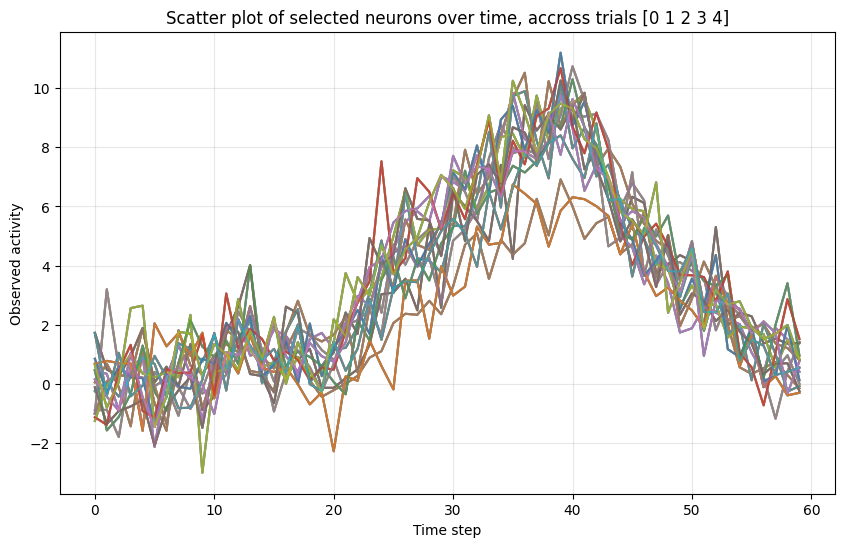

[[0.26561743]
 [0.24108268]
 [0.25847766]
 [0.17456241]
 [0.26896005]
 [0.25498414]
 [0.2661294 ]
 [0.17513028]
 [0.25016035]
 [0.27229603]
 [0.2473085 ]
 [0.25853358]
 [0.26236474]
 [0.27463701]
 [0.27446522]
 [0.22555167]]


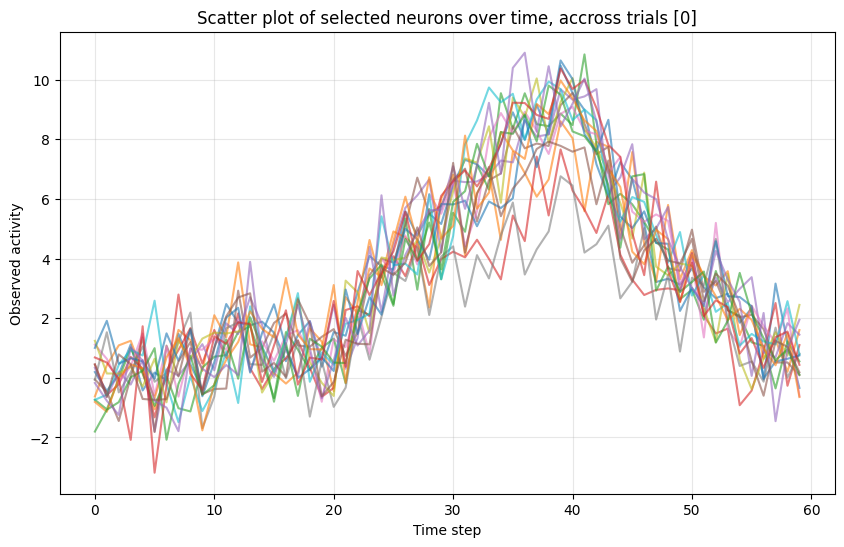

Plotting Latent States:


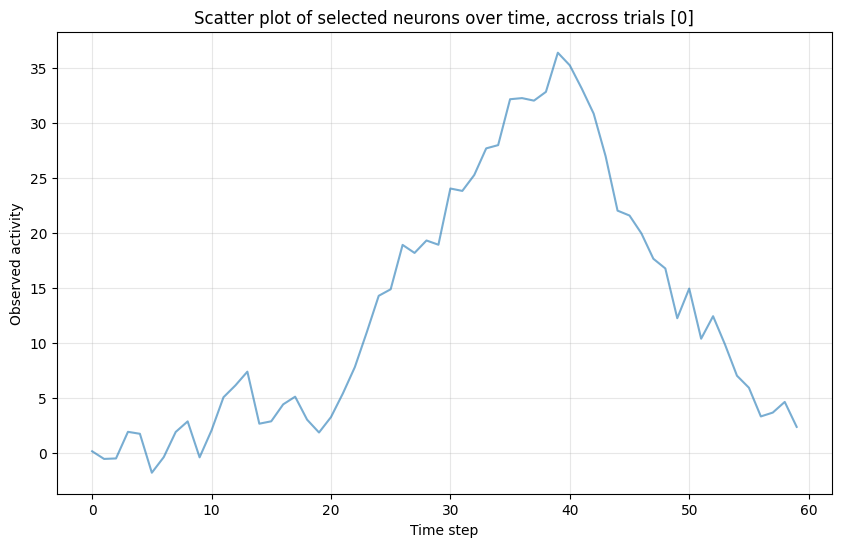

Plotting Inputs:


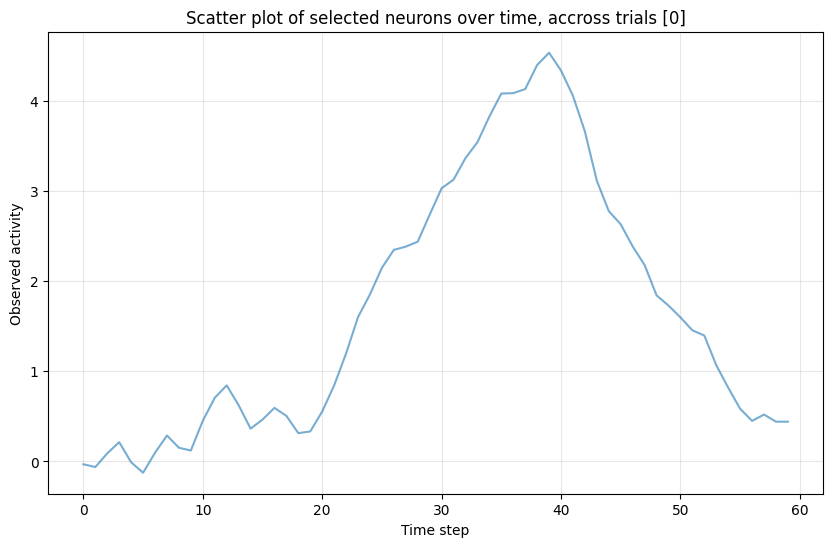

Phase portraits are visually defined for 2D and 3D systems. Your system is 1D.
Gramian visualization is explicitly set up for 2D and 3D systems. Your system is 1D.


In [2]:
from typing import Tuple
import numpy as np
from sklearn.decomposition import PCA
from scipy.linalg import lstsq
import scipy.linalg as la
from LDSParams import LDSParams
from Illustrator import Illustrator
from Simulator import Simulator
rng = np.random.default_rng()
# --- 1. System ID & Estimation Engine ---
def _estimate_all_parameters(
    observation: np.ndarray, 
    LatentDim: int, 
    InputDim: int
) -> Tuple[np.ndarray, np.ndarray, LDSParams]:
    """
    Performs System Identification to learn the physics (LDSParams) 
    and reconstructs the states/inputs.
    """
    T, N = observation.shape
    
    # STEP 1: INITIAL DECOMPOSITION (PCA)
    # We find a subspace that accounts for both internal state and external input
    pca = PCA(n_components=LatentDim + InputDim)
    z = pca.fit_transform(observation)
    
    # Initial split: Assume first components are latents (internal) 
    # and subsequent components are input-driven
    x_init = z[:, :LatentDim]
    u_init = z[:, LatentDim:]
    
    # STEP 2: LEARN DYNAMICS (System ID)
    # Solve x_{t+1} = A*x_t + B*u_t using Least Squares
    predictors = np.hstack([x_init[:-1], u_init[:-1]]) # (T-1, Latent+Input)
    targets = x_init[1:]                               # (T-1, Latent)
    
    sol, _, _, _ = lstsq(predictors, targets)
    A = sol[:LatentDim, :].T
    B = sol[LatentDim:, :].T
    
    # STEP 3: LEARN EMISSIONS (Mapping to Neurons)
    # Solve y_t = C*x_t
    C_lstsq, _, _, _ = lstsq(x_init, observation)
    C = C_lstsq.T # Transposed to match standard (Neurons, LatentDim) shape for np.matmul
    
    # STEP 4: ESTIMATE NOISE COVARIANCES
    # Q: Process noise (Dynamics error)
    x_pred = (A @ x_init[:-1].T + B @ u_init[:-1].T).T
    Q = np.atleast_2d(np.cov((x_init[1:] - x_pred).T))
    
    # R: Observation noise (Residual neural activity)
    # Note: We use C.T here to map back to the (Timepoints, Neurons) dimension
    R = np.atleast_2d(np.cov((observation - (x_init @ C.T)).T))
    
    # STEP 5: WRAP PARAMS
    lds = LDSParams(
        A=A, B=B, C=C, Q=Q, R=R,
        mu_0=x_init[0], 
        P_0=np.eye(LatentDim) * 0.1
    )
    
    # Returning the initial PCA estimates as the current "best guess"
    # In a more advanced version, you'd run a Kalman Smoother here using 'lds'
    return x_init, u_init, lds

#uses EM with simple gaussian prior
def _estimate_em_parameters(
    observation: np.ndarray, 
    LatentDim: int, 
    InputDim: int,
    prior_lambda: float = 1.0,  # Gaussian Prior strength (Ridge penalty)
    max_iter: int = 100,
    tol: float = 1e-5
) -> Tuple[np.ndarray, np.ndarray, LDSParams]:
    """
    Hybrid Subspace/EM System Identification.
    1. SVD/PCA to lock in Latent States (X) and Emissions (C).
    2. EM loop with Gaussian prior to find A, B, and unobserved Inputs (U).
    """
    T, N = observation.shape
    
    # --- PHASE 1: SUBSPACE EMISSIONS ---
    # Stack Y and perform SVD (via PCA) to decompose into States and C matrix
    pca = PCA(n_components=LatentDim)
    X = pca.fit_transform(observation)  # Shape: (T, LatentDim)
    C = pca.components_.T               # Shape: (N, LatentDim)
    
    # --- PHASE 2: EM INITIALIZATION ---
    # We use x_t to predict x_next
    x_t = X[:-1]
    x_next = X[1:]
    
    # Initialize A using simple least squares (assuming U=0 initially)
    A_lstsq, _, _, _ = lstsq(x_t, x_next)
    A = A_lstsq.T  # Shape: (LatentDim, LatentDim)
    
    # Initialize B randomly (small values) to break mathematical symmetry
    B = np.random.randn(LatentDim, InputDim) * 0.1
    
    # Initialize U
    U_est = np.zeros((T - 1, InputDim))
    
    # --- PHASE 3: THE EM LOOP ---
    for i in range(max_iter):
        A_old, B_old = A.copy(), B.copy()
        
        # ---------------------------------------------------------
        # E-Step: Estimate U given A, B, X
        # Objective: min || x_next - A*x_t - B*u_t ||^2 + lambda * || u_t ||^2
        # ---------------------------------------------------------
        # 1. Calculate the residual that A could not explain
        E = x_next - (A @ x_t.T).T  # Shape: (T-1, LatentDim)
        
        # 2. Ridge Regression formula to find U (Applying the Gaussian Prior)
        # u_t = (B^T B + lambda * I)^-1 B^T e_t
        ridge_inv = np.linalg.inv(B.T @ B + prior_lambda * np.eye(InputDim))
        U_est = E @ B @ ridge_inv  # Shape: (T-1, InputDim)
        
        # ---------------------------------------------------------
        # M-Step: Update A and B given X and U_est
        # Objective: min || x_next - [A B] * [x_t; u_t] ||^2
        # ---------------------------------------------------------
        predictors = np.hstack([x_t, U_est])  # Shape: (T-1, LatentDim + InputDim)
        Theta, _, _, _ = lstsq(predictors, x_next)
        
        A = Theta[:LatentDim, :].T
        B = Theta[LatentDim:, :].T
        
        # ---------------------------------------------------------
        # Convergence Check
        # ---------------------------------------------------------
        delta = np.linalg.norm(A - A_old) + np.linalg.norm(B - B_old)
        if delta < tol:
            print(f"EM converged at iteration {i+1}")
            break
    else:
        print(f"EM reached max iterations ({max_iter}) without full convergence.")
        
    # --- PHASE 4: ASSEMBLE SYSTEM ---
    # U_est is length T-1 (it drives the transitions). 
    # We pad it with a copy of the last input to align with the T-length observation array.
    U_full = np.vstack([U_est, U_est[-1:]])
    
    # Estimate Noise Covariances
    x_pred = (A @ x_t.T + B @ U_est.T).T
    Q = np.atleast_2d(np.cov((x_next - x_pred).T))
    R = np.atleast_2d(np.cov((observation - (X @ C.T)).T))
    
    # Wrap in LDS dataclass
    lds = LDSParams(
        A=A, B=B, C=C, Q=Q, R=R,
        mu_0=X[0], 
        P_0=np.eye(LatentDim) * 0.1
    )
    
    return X, U_full, lds
# --- 2. Required Interface for Demonstrator ---

#uses markovian prior for EM
def _estimate_markovian_gaussian_em(
    observation: np.ndarray, 
    LatentDim: int, 
    InputDim: int,
    prior_lambda: float = 10.0,  
    max_iter: int = 100,
    tol: float = 1e-5
) -> Tuple[np.ndarray, np.ndarray, LDSParams]:
    """
    Hybrid Subspace/EM System ID using a Gaussian Markovian Prior.
    Phase 1 strictly uses raw SVD to preserve the dynamic equilibrium point.
    """
    T, N = observation.shape
    
    # --- PHASE 1: SUBSPACE EMISSIONS (RAW SVD) ---
    # Perform SVD on the uncentered observation matrix
    U, S, Vt = np.linalg.svd(observation, full_matrices=False)
    
    # Truncate to the requested Latent Dimension (k)
    U_k = U[:, :LatentDim]
    S_k = np.diag(S[:LatentDim])
    V_k = Vt[:LatentDim, :].T  # Transpose to get shape (N, LatentDim)
    
    # Form the Latent States (X) and Emission Matrix (C)
    X = U_k @ S_k
    C = V_k
    
    # --- PHASE 2: EM INITIALIZATION ---
    x_t = X[:-1]
    x_next = X[1:]
    K = T - 1  # Number of transitions
    
    A_lstsq, _, _, _ = la.lstsq(x_t, x_next)
    A = A_lstsq.T  
    B = np.random.randn(LatentDim, InputDim) * 0.1
    U_est = np.zeros((K, InputDim))
    
    # Construct the 1D Laplacian matrix (L = D^T D)
    L = np.zeros((K, K))
    np.fill_diagonal(L, 2.0)
    np.fill_diagonal(L[1:], -1.0)
    np.fill_diagonal(L[:, 1:], -1.0)
    L[0, 0] = 1.0
    L[-1, -1] = 1.0
    
    # --- PHASE 3: THE EM LOOP ---
    for i in range(max_iter):
        A_old, B_old = A.copy(), B.copy()
        
        # E-Step: Estimate continuous U via Sylvester Equation
        E = x_next - (x_t @ A.T)
        A_sylv = prior_lambda * L
        B_sylv = B.T @ B
        Q_sylv = E @ B
        
        U_est = la.solve_sylvester(A_sylv, B_sylv, Q_sylv)
        
        # M-Step: Update A and B given X and U_est
        predictors = np.hstack([x_t, U_est])  
        Theta, _, _, _ = la.lstsq(predictors, x_next)
        
        A = Theta[:LatentDim, :].T
        B = Theta[LatentDim:, :].T
        
        # Convergence Check
        delta = np.linalg.norm(A - A_old) + np.linalg.norm(B - B_old)
        if delta < tol:
            print(f"Gaussian Markovian EM converged at iteration {i+1}")
            break
    else:
        print(f"Gaussian Markovian EM reached max iterations ({max_iter}).")
        
    # --- PHASE 4: ASSEMBLE SYSTEM ---
    U_full = np.vstack([U_est, U_est[-1:]])
    
    x_pred = (A @ x_t.T + B @ U_est.T).T
    Q = np.atleast_2d(np.cov((x_next - x_pred).T))
    R = np.atleast_2d(np.cov((observation - (X @ C.T)).T))
    
    lds = LDSParams(
        A=A, B=B, C=C, Q=Q, R=R,
        mu_0=X[0], 
        P_0=np.eye(LatentDim) * 0.1
    )
    
    return X, U_full, lds

def _estimate_hankel_markovian_em(
    observation: np.ndarray, 
    LatentDim: int, 
    InputDim: int,
    num_delays: int = 3,         # NEW: The size of our time-delay window
    prior_lambda: float = 10.0,  
    max_iter: int = 100,
    tol: float = 1e-5
) -> Tuple[np.ndarray, np.ndarray, LDSParams]:
    """
    Hybrid Subspace/EM System ID using a Time-Delay Embedding (Hankel Matrix).
    - Phase 1 stacks time steps to allow SVD to "see" rotations/complex eigenvalues.
    - Phase 3 enforces smooth physical inputs via the Sylvester equation.
    """
    T, N = observation.shape
    
    # --- PHASE 1: HANKEL TIME-DELAY EMBEDDING ---
    # Determine the length of our "stacked" time series
    T_h = T - num_delays + 1
    
    # Pre-allocate the Hankel matrix: (Time, Delays * Neurons)
    H = np.zeros((T_h, num_delays * N))
    
    # Stack the shifted observations side-by-side
    for i in range(num_delays):
        H[:, i*N : (i+1)*N] = observation[i : T_h+i, :]
        
    # Perform SVD on the Hankel matrix to extract motion-aware states
    U, S, Vt = np.linalg.svd(H, full_matrices=False)
    
    U_k = U[:, :LatentDim]
    S_k = np.diag(S[:LatentDim])
    X_h = U_k @ S_k  # Shape: (T_h, LatentDim)
    
    # Find the Emission Matrix (C) by mapping the latent states back to 
    # the un-shifted present-time observations.
    Y_aligned = observation[:T_h, :]
    C_lstsq, _, _, _ = la.lstsq(X_h, Y_aligned)
    C = C_lstsq.T
    
    # --- PHASE 2: EM INITIALIZATION ---
    x_t = X_h[:-1]
    x_next = X_h[1:]
    K = T_h - 1  # Number of transitions in our delayed window
    
    A_lstsq, _, _, _ = la.lstsq(x_t, x_next)
    A = A_lstsq.T  
    B = np.random.randn(LatentDim, InputDim) * 0.1
    U_est = np.zeros((K, InputDim))
    
    # 1D Laplacian matrix for the Markovian derivative penalty
    L = np.zeros((K, K))
    np.fill_diagonal(L, 2.0)
    np.fill_diagonal(L[1:], -1.0)
    np.fill_diagonal(L[:, 1:], -1.0)
    L[0, 0] = 1.0
    L[-1, -1] = 1.0
    
    # --- PHASE 3: THE EM LOOP ---
    for i in range(max_iter):
        A_old, B_old = A.copy(), B.copy()
        
        # E-Step: Solve Sylvester Equation for continuous U
        E = x_next - (x_t @ A.T)
        A_sylv = prior_lambda * L
        B_sylv = B.T @ B
        Q_sylv = E @ B
        
        U_est = la.solve_sylvester(A_sylv, B_sylv, Q_sylv)
        
        # M-Step: Update A and B
        predictors = np.hstack([x_t, U_est])  
        Theta, _, _, _ = la.lstsq(predictors, x_next)
        
        A = Theta[:LatentDim, :].T
        B = Theta[LatentDim:, :].T
        
        if np.linalg.norm(A - A_old) + np.linalg.norm(B - B_old) < tol:
            print(f"Hankel EM converged at iteration {i+1}")
            break
    else:
        print(f"Hankel EM reached max iterations ({max_iter}).")
        
    # --- PHASE 4: RECONSTRUCTION & PADDING ---
    # Because we stacked 'num_delays' frames, our X and U matrices are slightly short.
    # We simulate the learned physics forward to pad them perfectly to length T.
    
    U_full = np.zeros((T, InputDim))
    U_full[:K, :] = U_est
    # Assume the input stays constant for the final few missing frames
    for t in range(K, T):
        U_full[t, :] = U_est[-1, :]
        
    X_full = np.zeros((T, LatentDim))
    X_full[:T_h, :] = X_h
    # Forecast the states using the estimated A and B matrices
    for t in range(T_h, T):
        X_full[t, :] = A @ X_full[t-1, :] + B @ U_full[t-1, :]
        
    # Calculate Noise Covariances on the fully reconstructed trajectory
    x_pred = (A @ X_full[:-1].T + B @ U_full[:-1].T).T
    Q = np.atleast_2d(np.cov((X_full[1:] - x_pred).T))
    R = np.atleast_2d(np.cov((observation - (X_full @ C.T)).T))
    
    lds = LDSParams(
        A=A, B=B, C=C, Q=Q, R=R,
        mu_0=X_full[0], 
        P_0=np.eye(LatentDim) * 0.1
    )
    
    return X_full, U_full, lds

def estimate_latent_and_input(observation: np.ndarray, LatentDim: int, InputDim: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Standard interface. Calls the engine but hides the LDSParams from the demonstrator.
    """
    # Ensure observation is 2D (Timepoints, Neurons)
    if observation.ndim != 2:
        raise ValueError(f"Expected 2D observation, got {observation.shape}")
        
    latent_states, inputs, _ = _estimate_all_parameters(observation, LatentDim, InputDim)
    return latent_states, inputs

# --- 3. Execution on Batched Data ---
# Load data (Trials, Timepoints, Neurons)
data = np.load("ExampleDataset.npy") 

# If you want to process the FIRST trial:
trial_idx = 0
obs_trial = data[trial_idx] # This is (Timepoints, Neurons)

# Run the estimation
latents, inputs,lds = _estimate_all_parameters(obs_trial, LatentDim=4, InputDim=10)
latents, inputs,lds = _estimate_markovian_gaussian_em(data[0],1,1)
def input(time,data):
    return inputs[time]
print(f"Processed Trial {trial_idx}:")
print(f"Latents Shape: {latents.shape}") # (Timepoints, 3)
print(f"Inputs Shape: {inputs.shape}")   # (Timepoints, 3)
ill = Illustrator(data)
ill.plot_general()
print(lds.C)
sim = Simulator([lds.A,lds.B,lds.C,lds.Q,lds.R])
fake_data = sim.generate_data(1,60,rng.multivariate_normal(lds.mu_0,lds.P_0),input)
fake_ill = Illustrator(fake_data)
fake_ill.plot_general()

# 1. Add a dummy "trial" dimension
latents_3d = np.expand_dims(latents, axis=0) # Shape becomes (1, Timepoints, LatentDim)
inputs_3d = np.expand_dims(inputs, axis=0)   # Shape becomes (1, Timepoints, InputDim)

# 2. Plot Latents
ill_latents = Illustrator(latents_3d)
print("Plotting Latent States:")
ill_latents.plot_general() 

# 3. Plot Inputs
ill_inputs = Illustrator(inputs_3d)
print("Plotting Inputs:")
ill_inputs.plot_general()
sim.plot_phase_portrait()
sim.plot_gramian_directions()

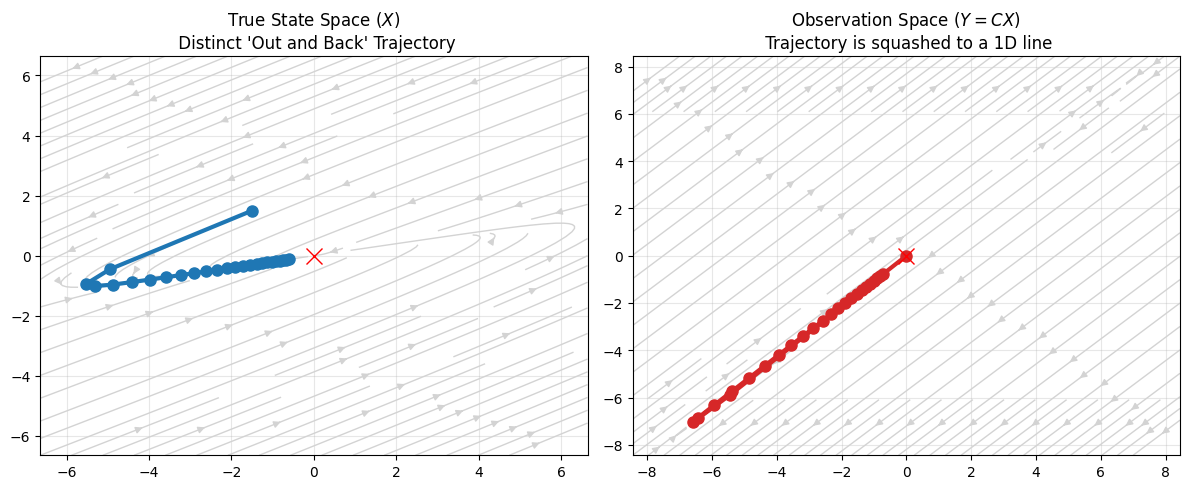

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Engineer an 'A' matrix with highly skewed eigenvectors
V = np.array([[1.0, 1.0], [0.2, 0.5]]) 
Lambda = np.diag([0.9, 0.3])
A_true = V @ Lambda @ np.linalg.inv(V)

# 2. The poorly conditioned C matrix
C_skewed = np.array([[1.0, 1.1], [1.1, 1.0]])

# 3. Simulate the trajectory
steps = 25
X_path = np.zeros((steps, 2))
Y_path = np.zeros((steps, 2))
X_path[0] = np.array([-1.5, 1.5]) # Start position

for t in range(1, steps):
    X_path[t] = A_true @ X_path[t-1]
    Y_path[t] = C_skewed @ X_path[t]

# Dynamically calculate limits so it perfectly fits
max_X = np.max(np.abs(X_path)) * 1.2
max_Y = np.max(np.abs(Y_path)) * 1.2

# 4. Generate the Vector Field
x_val = np.linspace(-max_X, max_X, 20)
y_val = np.linspace(-max_X, max_X, 20)
X_grid, Y_grid = np.meshgrid(x_val, y_val)

U_X = A_true[0,0]*X_grid + A_true[0,1]*Y_grid - X_grid
V_X = A_true[1,0]*X_grid + A_true[1,1]*Y_grid - Y_grid

Theta_true = C_skewed @ A_true @ np.linalg.inv(C_skewed)
y_val_Y = np.linspace(-max_Y, max_Y, 20)
X_grid_Y, Y_grid_Y = np.meshgrid(np.linspace(-max_Y, max_Y, 20), y_val_Y)
U_Y = Theta_true[0,0]*X_grid_Y + Theta_true[0,1]*Y_grid_Y - X_grid_Y
V_Y = Theta_true[1,0]*X_grid_Y + Theta_true[1,1]*Y_grid_Y - Y_grid_Y

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].streamplot(X_grid, Y_grid, U_X, V_X, color='lightgray', linewidth=1, density=1.2)
axes[0].plot(X_path[:, 0], X_path[:, 1], 'o-', color='tab:blue', linewidth=3, markersize=8)
axes[0].plot(0, 0, 'rx', markersize=12)
axes[0].set_title("True State Space ($X$) \n Distinct 'Out and Back' Trajectory")
axes[0].set_xlim([-max_X, max_X]); axes[0].set_ylim([-max_X, max_X])
axes[0].grid(True, alpha=0.3)

axes[1].streamplot(X_grid_Y, Y_grid_Y, U_Y, V_Y, color='lightgray', linewidth=1, density=1.2)
axes[1].plot(Y_path[:, 0], Y_path[:, 1], 'o-', color='tab:red', linewidth=3, markersize=8)
axes[1].plot(0, 0, 'rx', markersize=12)
axes[1].set_title("Observation Space ($Y = CX$) \n Trajectory is squashed to a 1D line")
axes[1].set_xlim([-max_Y, max_Y]); axes[1].set_ylim([-max_Y, max_Y])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

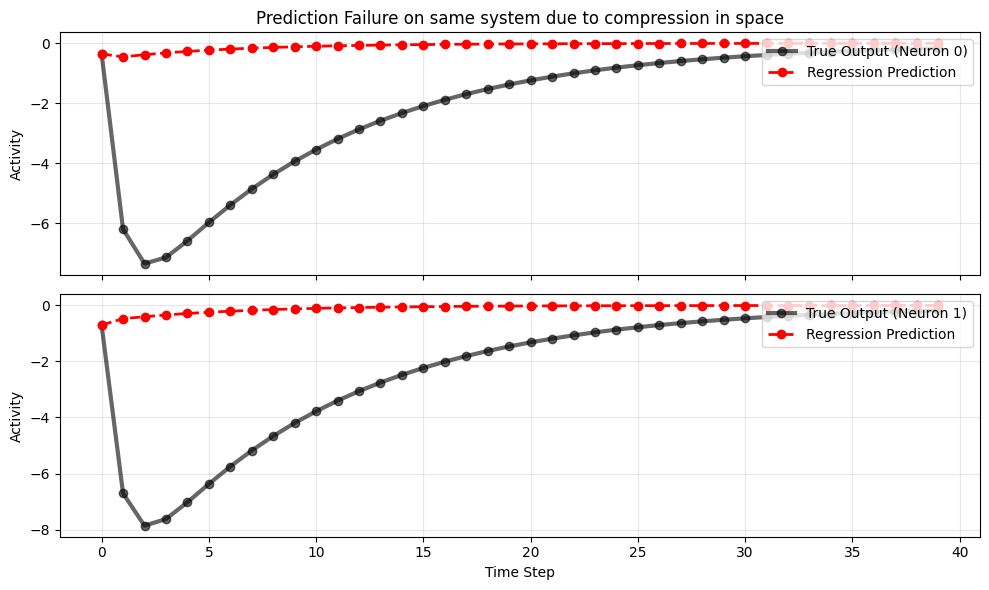

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

# 1. System Setup
V = np.array([[1.0, 1.0], [0.2, 0.5]])
Lambda = np.diag([0.9, 0.3]) # True system has a slow decay (0.9)
A_true = V @ Lambda @ np.linalg.inv(V)
C_skewed = np.array([[1.0, 1.1], [1.1, 1.0]])

# 2. Train the Model with Noisy Data
T_train = 1000
X_train = np.zeros((T_train, 2))
Y_noisy = np.zeros((T_train, 2))

Q = np.eye(2) * 0.01  # Process noise
R = np.eye(2) * 0.1   # Observation noise 

for t in range(1, T_train):
    X_train[t] = A_true @ X_train[t-1] + np.random.multivariate_normal([0,0], Q)
    Y_noisy[t] = C_skewed @ X_train[t] + np.random.multivariate_normal([0,0], R)

# Least Squares Regression: Y_{t+1} = Theta * Y_t
Theta_est, _, _, _ = la.lstsq(Y_noisy[:-1], Y_noisy[1:])
Theta_est = Theta_est.T

# 3. Test the Model (Superimpose True vs. Predicted)
T_test = 40
Y_true_test = np.zeros((T_test, 2))
Y_pred_test = np.zeros((T_test, 2))

# Set a shared starting condition
x_curr = np.array([-2.0, 1.5])
Y_true_test[0] = C_skewed @ x_curr
Y_pred_test[0] = Y_true_test[0]

for t in range(1, T_test):
    # Evolve TRUE physics
    x_curr = A_true @ x_curr
    Y_true_test[t] = C_skewed @ x_curr
    
    # Evolve PREDICTED physics using the regression matrix
    Y_pred_test[t] = Theta_est @ Y_pred_test[t-1]

# --- PLOTTING ---
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for i in range(2):
    axes[i].plot(Y_true_test[:, i], 'ko-', linewidth=3, markersize=6, alpha=0.6, label=f"True Output (Neuron {i})")
    axes[i].plot(Y_pred_test[:, i], 'ro--', linewidth=2, markersize=6, label=f"Regression Prediction")
    axes[i].set_ylabel("Activity")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc='upper right')

axes[0].set_title("Prediction Failure on same system due to compression in space")
axes[1].set_xlabel("Time Step")

plt.tight_layout()
plt.show()

Running Method 1: Independent Prior (Lambda = 0.0)...
Hankel EM reached max iterations (30).
[[0.00028019 0.0026906 ]
 [0.0026906  0.0258373 ]]
Running Method 2: Markovian Prior (Lambda = 50.0)...
Hankel EM reached max iterations (30).

FIT PERFORMANCE (VAF)
Method 1 (Independent Prior): 95.80%
Method 2 (Markovian Prior):   95.80%



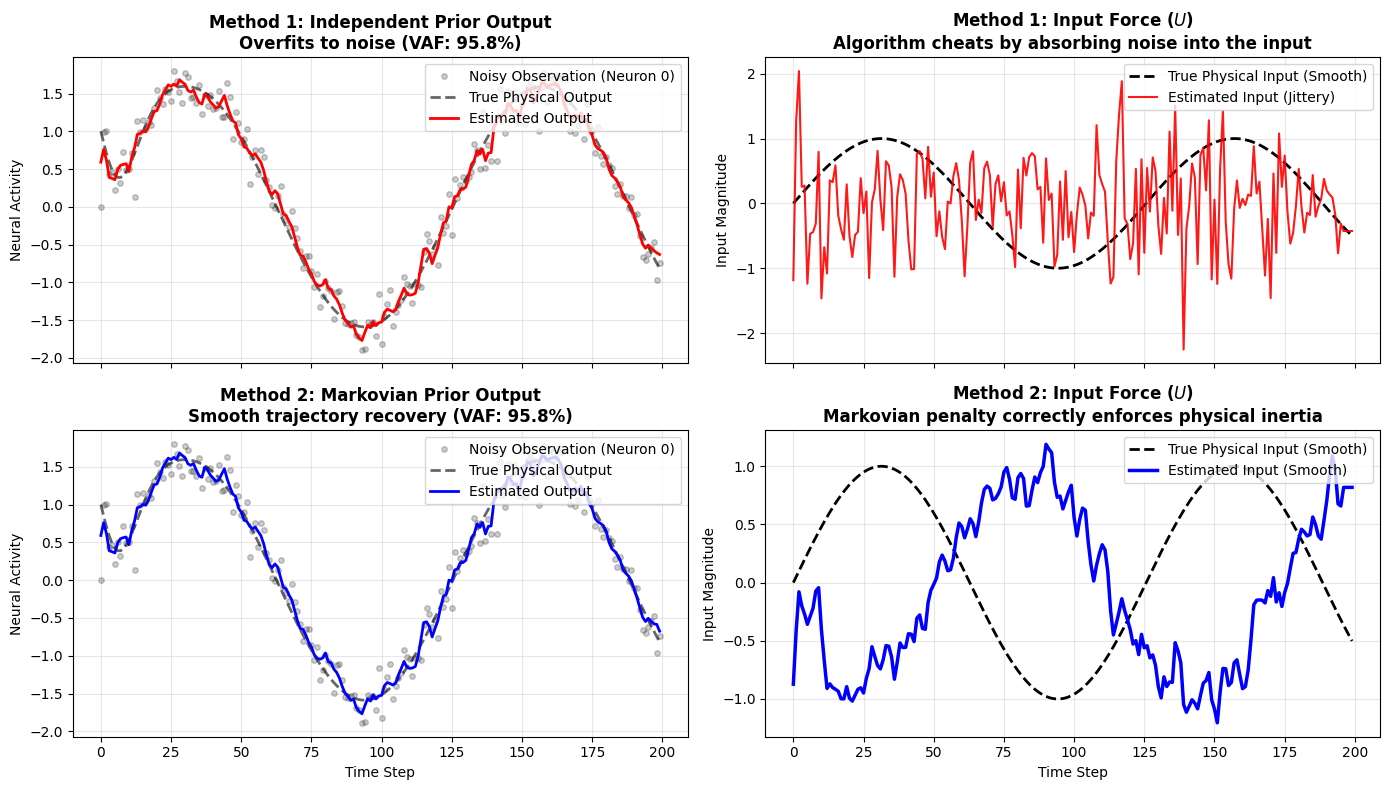

In [11]:
import numpy as np
from Illustrator import Illustrator
# Make sure to import your estimator and LDSParams
# from your_module import _estimate_hankel_markovian_em

# ==========================================
# 1. SYSTEM DEFINITION & DATA GENERATION
# ==========================================
T = 200
U_true = np.sin(np.arange(T) * 0.05).reshape(-1, 1) # Smooth physical input

# A physical system with inertia
A_true = np.array([[0.85, 0.2], [-0.2, 0.85]])
B_true = np.array([[0.5], [0.1]])
C_true = np.array([[1.0, 0.0], [0.0, 1.0], [0.5, 0.5]])

X_true = np.zeros((T, 2))
Y_noisy = np.zeros((T, 3))
X_true[0] = [1.0, 0.0]

for t in range(1, T):
    X_true[t] = A_true @ X_true[t-1] + B_true @ U_true[t-1]
    Y_noisy[t] = C_true @ X_true[t] + np.random.randn(3) * 0.2

# The noiseless "true" output for clean plotting
Y_true = (C_true @ X_true.T).T

# ==========================================
# 2. RUN YOUR ESTIMATORS
# ==========================================
print("Running Method 1: Independent Prior (Lambda = 0.0)...")
# By setting Lambda to 0, we disable the Markovian penalty (it becomes a pure least-squares fit)
X_indep, U_indep, lds_indep = _estimate_hankel_markovian_em(
    Y_noisy, LatentDim=2, InputDim=1, num_delays=3, prior_lambda=0.0, max_iter=30
)
Y_pred_indep = X_indep @ lds_indep.C.T
print(lds_indep.Q)
print("Running Method 2: Markovian Prior (Lambda = 50.0)...")
# Engaging the Markovian penalty to enforce smooth physical limits
X_markov, U_markov, lds_markov = _estimate_hankel_markovian_em(
    Y_noisy, LatentDim=2, InputDim=1, num_delays=3, prior_lambda=50.0, max_iter=30
)
Y_pred_markov = X_markov @ lds_markov.C.T

# ==========================================
# 3. CALCULATE AND DISPLAY VAF
# ==========================================
vaf_indep = 100 * (1 - np.var(Y_noisy - Y_pred_indep) / np.var(Y_noisy))
vaf_markov = 100 * (1 - np.var(Y_noisy - Y_pred_markov) / np.var(Y_noisy))

print(f"\n========================================")
print(f"FIT PERFORMANCE (VAF)")
print(f"========================================")
print(f"Method 1 (Independent Prior): {vaf_indep:.2f}%")
print(f"Method 2 (Markovian Prior):   {vaf_markov:.2f}%\n")

# Address Basis Ambiguity: Scale the estimated U to match the magnitude of True U for plotting
U_indep_scaled = U_indep * (np.std(U_true) / np.std(U_indep))
U_markov_scaled = U_markov * (np.std(U_true) / np.std(U_markov))

# ==========================================
# 4. VISUALIZATION (REPORT-READY LABELS)
# ==========================================
import matplotlib.pyplot as plt

# Set up a 2x2 grid for the report
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

# --- TOP ROW: METHOD 1 (INDEPENDENT PRIOR) ---

# Top-Left: Outputs
axes[0, 0].plot(Y_noisy[:, 0], 'k.', alpha=0.2, markersize=8, label="Noisy Observation (Neuron 0)")
axes[0, 0].plot(Y_true[:, 0], 'k--', lw=2, alpha=0.6, label="True Physical Output")
axes[0, 0].plot(Y_pred_indep[:, 0], 'r-', lw=2, label="Estimated Output")
axes[0, 0].set_title(f"Method 1: Independent Prior Output\nOverfits to noise (VAF: {vaf_indep:.1f}%)", fontweight='bold')
axes[0, 0].set_ylabel("Neural Activity")
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# Top-Right: Inputs
axes[0, 1].plot(U_true, 'k--', lw=2, label="True Physical Input (Smooth)")
axes[0, 1].plot(U_indep_scaled, 'r-', lw=1.5, alpha=0.9, label="Estimated Input (Jittery)")
axes[0, 1].set_title("Method 1: Input Force ($U$)\nAlgorithm cheats by absorbing noise into the input", fontweight='bold')
axes[0, 1].set_ylabel("Input Magnitude")
axes[0, 1].legend(loc='upper right')
axes[0, 1].grid(True, alpha=0.3)


# --- BOTTOM ROW: METHOD 2 (MARKOVIAN PRIOR) ---

# Bottom-Left: Outputs
axes[1, 0].plot(Y_noisy[:, 0], 'k.', alpha=0.2, markersize=8, label="Noisy Observation (Neuron 0)")
axes[1, 0].plot(Y_true[:, 0], 'k--', lw=2, alpha=0.6, label="True Physical Output")
axes[1, 0].plot(Y_pred_markov[:, 0], 'b-', lw=2, label="Estimated Output")
axes[1, 0].set_title(f"Method 2: Markovian Prior Output\nSmooth trajectory recovery (VAF: {vaf_markov:.1f}%)", fontweight='bold')
axes[1, 0].set_xlabel("Time Step")
axes[1, 0].set_ylabel("Neural Activity")
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

# Bottom-Right: Inputs
axes[1, 1].plot(U_true, 'k--', lw=2, label="True Physical Input (Smooth)")
axes[1, 1].plot(U_markov_scaled, 'b-', lw=2.5, label="Estimated Input (Smooth)")
axes[1, 1].set_title("Method 2: Input Force ($U$)\nMarkovian penalty correctly enforces physical inertia", fontweight='bold')
axes[1, 1].set_xlabel("Time Step")
axes[1, 1].set_ylabel("Input Magnitude")
axes[1, 1].legend(loc='upper right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Running SVD Benchmark...


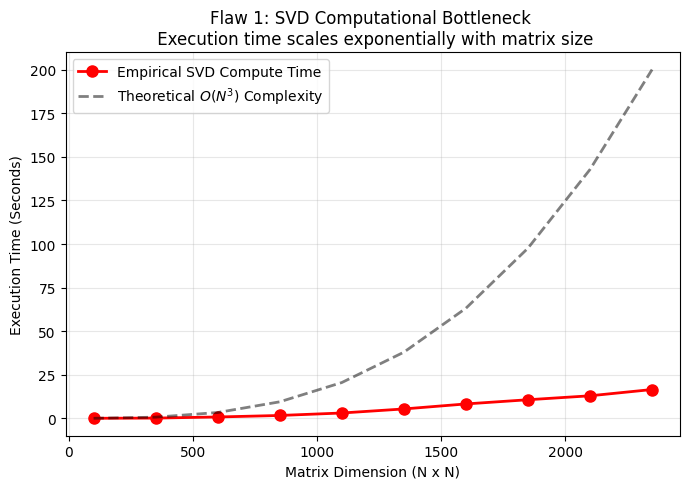

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time

# --- FLAW 1: THE COMPUTATIONAL COST OF SVD ---

matrix_sizes = np.arange(100, 2500, 250)
svd_times = []

print("Running SVD Benchmark...")
for size in matrix_sizes:
    # Simulate a square data matrix (e.g., a massive Hankel or covariance matrix)
    Y_dummy = np.random.randn(size, size)
    
    start_time = time.time()
    # Perform standard SVD
    np.linalg.svd(Y_dummy, full_matrices=False)
    end_time = time.time()
    
    svd_times.append(end_time - start_time)

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(matrix_sizes, svd_times, 'ro-', linewidth=2, markersize=8, label="Empirical SVD Compute Time")

# Add a theoretical O(N^3) curve for reference, scaled to match the empirical data
theoretical_curve = (matrix_sizes / matrix_sizes[0])**3 * svd_times[0]
ax.plot(matrix_sizes, theoretical_curve, 'k--', linewidth=2, alpha=0.5, label="Theoretical $O(N^3)$ Complexity")

ax.set_title("Flaw 1: SVD Computational Bottleneck \n Execution time scales exponentially with matrix size")
ax.set_xlabel("Matrix Dimension (N x N)")
ax.set_ylabel("Execution Time (Seconds)")
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

<>:57: SyntaxWarning: invalid escape sequence '\h'
<>:58: SyntaxWarning: invalid escape sequence '\h'
<>:58: SyntaxWarning: invalid escape sequence '\h'
<>:63: SyntaxWarning: invalid escape sequence '\h'
<>:57: SyntaxWarning: invalid escape sequence '\h'
<>:58: SyntaxWarning: invalid escape sequence '\h'
<>:58: SyntaxWarning: invalid escape sequence '\h'
<>:63: SyntaxWarning: invalid escape sequence '\h'
C:\Users\hassa\AppData\Local\Temp\ipykernel_14932\3386434181.py:57: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_title(f"Estimated State Space ($\hat{{X}}$ via Standard SVD)\nGeometry Crushed (Eigs: {est_eigs[0].real:.2f}, {est_eigs[1].real:.2f} Real)")
C:\Users\hassa\AppData\Local\Temp\ipykernel_14932\3386434181.py:58: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_xlabel("$\hat{x}_1$"); axes[1].set_ylabel("$\hat{x}_2$")
C:\Users\hassa\AppData\Local\Temp\ipykernel_14932\3386434181.py:58: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_xlabel("$\hat{x}

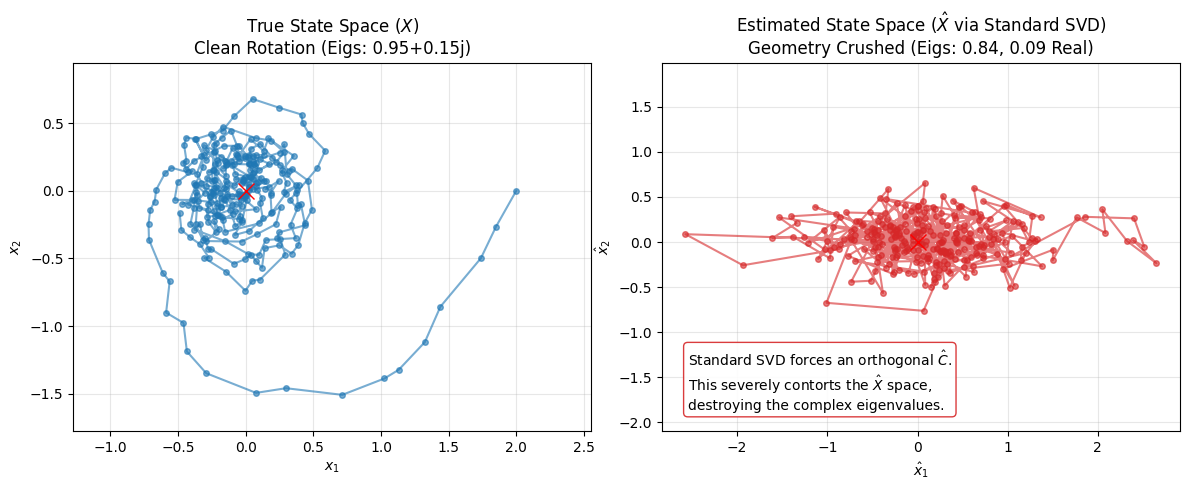

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

# --- FLAW 2: STATE CONTORTION DUE TO NON-ORTHOGONAL C ---

# 1. True System: A clean, slow rotation (Complex Eigenvalues)
A_rot = np.array([[0.95, 0.15], 
                  [-0.15, 0.95]])
# True Lens: Non-orthogonal/Skewed (from your handwritten notes)
C_skewed = np.array([[1.0, 1.1], 
                     [1.1, 1.0],
                     [0.5, 0.5]]) # Added a 3rd dimension to make SVD work harder

# Generate 300 steps of autonomous spiraling data with slight noise
T = 300
X_true = np.zeros((T, 2))
Y_noisy = np.zeros((T, 3))

# Start away from the origin to show the spiral
X_true[0] = [2.0, 0.0] 

Q = np.eye(2) * 0.005 # Process noise
R = np.eye(3) * 0.05  # Observation noise

for t in range(1, T):
    X_true[t] = A_rot @ X_true[t-1] + np.random.multivariate_normal([0,0], Q)
    Y_noisy[t] = C_skewed @ X_true[t] + np.random.multivariate_normal([0,0,0], R)

# 2. The Failed SVD Estimator (Time-Blind)
# SVD assumes C is perfectly orthogonal, forcing X to absorb the skew
U, S, Vt = np.linalg.svd(Y_noisy, full_matrices=False)
X_est_svd = U[:, :2] @ np.diag(S[:2])

# Regression to find estimated A
A_est_svd, _, _, _ = la.lstsq(X_est_svd[:-1], X_est_svd[1:])
A_est_svd = A_est_svd.T

# Calculate Eigenvalues for proof
true_eigs = np.linalg.eigvals(A_rot)
est_eigs = np.linalg.eigvals(A_est_svd)

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: True State Space (The perfect spiral)
axes[0].plot(X_true[:, 0], X_true[:, 1], 'o-', color='tab:blue', alpha=0.6, markersize=4)
axes[0].plot(0, 0, 'rx', markersize=12)
axes[0].set_title(f"True State Space ($X$)\nClean Rotation (Eigs: {true_eigs[0]:.2f})")
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$x_2$")
axes[0].grid(True, alpha=0.3)
axes[0].axis('equal')

# Plot 2: Estimated State Space (The contorted mess)
axes[1].plot(X_est_svd[:, 0], X_est_svd[:, 1], 'o-', color='tab:red', alpha=0.6, markersize=4)
axes[1].plot(0, 0, 'rx', markersize=12)
axes[1].set_title(f"Estimated State Space ($\hat{{X}}$ via Standard SVD)\nGeometry Crushed (Eigs: {est_eigs[0].real:.2f}, {est_eigs[1].real:.2f} Real)")
axes[1].set_xlabel("$\hat{x}_1$"); axes[1].set_ylabel("$\hat{x}_2$")
axes[1].grid(True, alpha=0.3)
axes[1].axis('equal')

# Add an annotation explaining the failure
axes[1].text(0.05, 0.05, "Standard SVD forces an orthogonal $\hat{C}$.\nThis severely contorts the $\hat{X}$ space,\ndestroying the complex eigenvalues.", 
        transform=axes[1].transAxes, fontsize=10, verticalalignment='bottom', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='tab:red'))

plt.tight_layout()
plt.show()

<>:64: SyntaxWarning: invalid escape sequence '\h'
<>:65: SyntaxWarning: invalid escape sequence '\h'
<>:65: SyntaxWarning: invalid escape sequence '\h'
<>:64: SyntaxWarning: invalid escape sequence '\h'
<>:65: SyntaxWarning: invalid escape sequence '\h'
<>:65: SyntaxWarning: invalid escape sequence '\h'
C:\Users\hassa\AppData\Local\Temp\ipykernel_14932\3088399354.py:64: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_title(f"Estimated State Space ($\hat{{X}}$ via Hankel SVD)\nGeometry Protected (Eigs: {est_eigs[0]:.2f})")
C:\Users\hassa\AppData\Local\Temp\ipykernel_14932\3088399354.py:65: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_xlabel("$\hat{x}_1$"); axes[1].set_ylabel("$\hat{x}_2$")
C:\Users\hassa\AppData\Local\Temp\ipykernel_14932\3088399354.py:65: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_xlabel("$\hat{x}_1$"); axes[1].set_ylabel("$\hat{x}_2$")


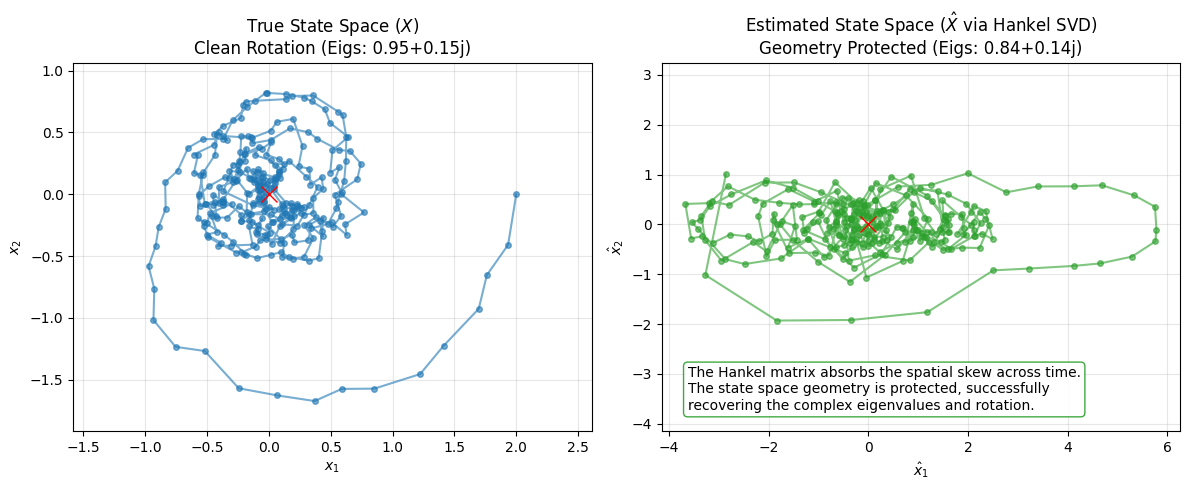

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

# --- THE HANKEL SOLUTION: PROTECTING THE STATE SPACE ---

# 1. True System (Identical to the Flaw 2 script)
A_rot = np.array([[0.95, 0.15], 
                  [-0.15, 0.95]]) # Complex Eigenvalues

C_skewed = np.array([[1.0, 1.1], 
                     [1.1, 1.0],
                     [0.5, 0.5]]) # Non-orthogonal "lens"

# Generate 300 steps of autonomous spiraling data with slight noise
T = 300
X_true = np.zeros((T, 2))
Y_noisy = np.zeros((T, 3))
X_true[0] = [2.0, 0.0] 

Q = np.eye(2) * 0.005 # Process noise
R = np.eye(3) * 0.05  # Observation noise

for t in range(1, T):
    X_true[t] = A_rot @ X_true[t-1] + np.random.multivariate_normal([0,0], Q)
    Y_noisy[t] = C_skewed @ X_true[t] + np.random.multivariate_normal([0,0,0], R)

# 2. The Successful Hankel Estimator
num_delays = 4
T_h = T - num_delays + 1
N = 3 # Number of neurons

# Stack the time-delay "video" frames
H = np.zeros((T_h, num_delays * N))
for i in range(num_delays):
    H[:, i*N:(i+1)*N] = Y_noisy[i:T_h+i, :]

# SVD on the Hankel matrix (Forces Gamma to be orthogonal, protecting X)
U, S, Vt = np.linalg.svd(H, full_matrices=False)
X_est_hankel = U[:, :2] @ np.diag(S[:2])

# Regression to find estimated A
A_est_hankel, _, _, _ = la.lstsq(X_est_hankel[:-1], X_est_hankel[1:])
A_est_hankel = A_est_hankel.T

# Calculate Eigenvalues for proof
true_eigs = np.linalg.eigvals(A_rot)
est_eigs = np.linalg.eigvals(A_est_hankel)

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: True State Space (The perfect spiral)
axes[0].plot(X_true[:, 0], X_true[:, 1], 'o-', color='tab:blue', alpha=0.6, markersize=4)
axes[0].plot(0, 0, 'rx', markersize=12)
axes[0].set_title(f"True State Space ($X$)\nClean Rotation (Eigs: {true_eigs[0]:.2f})")
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$x_2$")
axes[0].grid(True, alpha=0.3)
axes[0].axis('equal')

# Plot 2: Estimated State Space (The protected spiral)
axes[1].plot(X_est_hankel[:, 0], X_est_hankel[:, 1], 'o-', color='tab:green', alpha=0.6, markersize=4)
axes[1].plot(0, 0, 'rx', markersize=12)
axes[1].set_title(f"Estimated State Space ($\hat{{X}}$ via Hankel SVD)\nGeometry Protected (Eigs: {est_eigs[0]:.2f})")
axes[1].set_xlabel("$\hat{x}_1$"); axes[1].set_ylabel("$\hat{x}_2$")
axes[1].grid(True, alpha=0.3)
axes[1].axis('equal')

# Add an annotation explaining the success
axes[1].text(0.05, 0.05, "The Hankel matrix absorbs the spatial skew across time.\nThe state space geometry is protected, successfully\nrecovering the complex eigenvalues and rotation.", 
        transform=axes[1].transAxes, fontsize=10, verticalalignment='bottom', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='tab:green'))

plt.tight_layout()
plt.show()

Running Standard Markovian EM...
Gaussian Markovian EM reached max iterations (30).
Running Hankel Markovian EM...
Hankel EM reached max iterations (30).


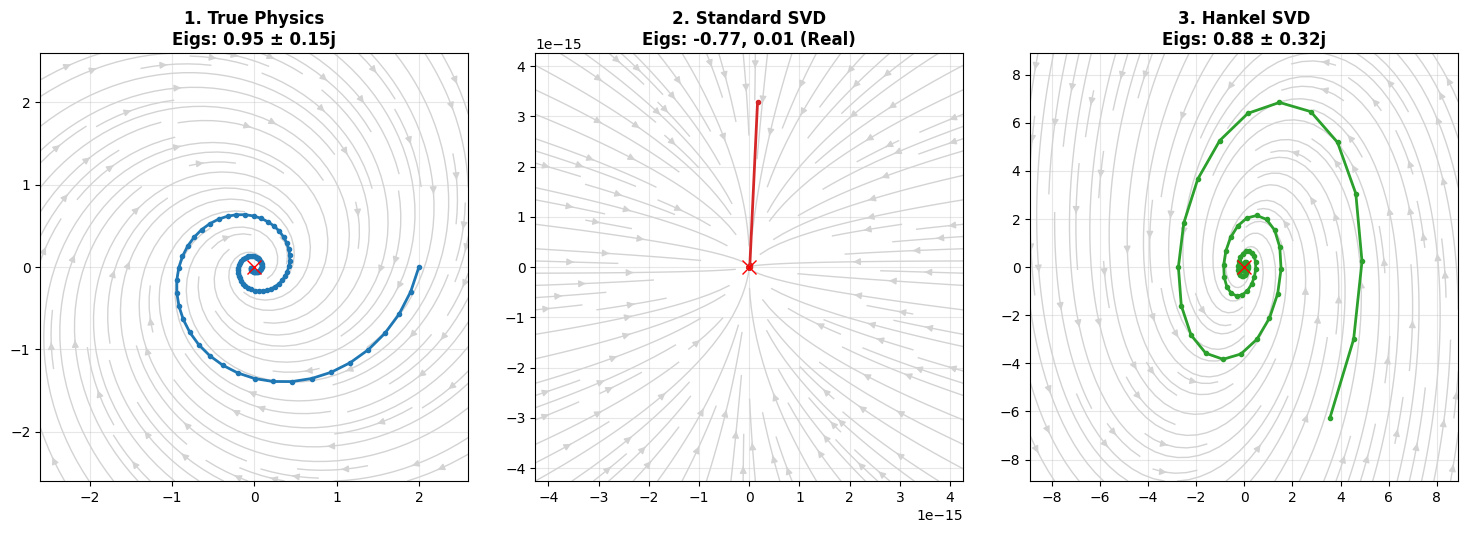

In [9]:
import numpy as np
import matplotlib.pyplot as plt
# Assuming your functions are imported from your module
# from your_module import _estimate_markovian_gaussian_em, _estimate_hankel_markovian_em, LDSParams

# ==========================================
# 1. SYSTEM SETUP
# ==========================================
A_rot = np.array([[0.95, 0.15], 
                  [-0.15, 0.95]]) # True physical rotation

C_skewed = np.array([[1.0, 1.1], 
                     [1.1, 1.0],
                     [0.5, 0.5]]) # Non-orthogonal "lens"

T = 300
np.random.seed(42) # Locked for consistent plots
X_true = np.zeros((T, 2))
Y_noisy = np.zeros((T, 3))
X_true[0] = [2.0, 0.0] 

Q = np.eye(2) * 0.005
R = np.eye(3) * 0.05 

# Autonomous simulation (no inputs) to test pure state dynamics
for t in range(1, T):
    X_true[t] = A_rot @ X_true[t-1] + np.random.multivariate_normal([0,0], Q)
    Y_noisy[t] = C_skewed @ X_true[t] + np.random.multivariate_normal([0,0,0], R)

# ==========================================
# 2. RUN YOUR PRE-BUILT ESTIMATORS
# ==========================================
print("Running Standard Markovian EM...")
X_est_std, _, lds_std = _estimate_markovian_gaussian_em(
    Y_noisy, LatentDim=2, InputDim=1, prior_lambda=50.0, max_iter=30
)

print("Running Hankel Markovian EM...")
X_est_hankel, _, lds_hankel = _estimate_hankel_markovian_em(
    Y_noisy, LatentDim=2, InputDim=1, num_delays=16, prior_lambda=50.0, max_iter=30
)

# ==========================================
# 3. PHASE PORTRAIT GENERATOR
# ==========================================
def plot_phase_portrait(ax, A, start_pt, title, color):
    """Generates the theoretical vector field and a clean path for a given A matrix"""
    steps = 100
    traj = np.zeros((steps, 2))
    traj[0] = start_pt
    for t in range(1, steps):
        traj[t] = A @ traj[t-1]
        
    max_val = np.max(np.abs(traj)) * 1.3
    if max_val == 0 or np.isnan(max_val): max_val = 2.0 # Safety fallback
    
    x = np.linspace(-max_val, max_val, 20)
    y = np.linspace(-max_val, max_val, 20)
    X_grid, Y_grid = np.meshgrid(x, y)
    
    # Vector Field: dX = (A - I)X
    u = (A[0, 0] - 1) * X_grid + A[0, 1] * Y_grid
    v = A[1, 0] * X_grid + (A[1, 1] - 1) * Y_grid
    
    ax.streamplot(X_grid, Y_grid, u, v, color='lightgray', linewidth=1, density=1.2)
    ax.plot(traj[:, 0], traj[:, 1], 'o-', color=color, markersize=3, linewidth=2)
    ax.plot(0, 0, 'rx', markersize=10)
    
    eigs = np.linalg.eigvals(A)
    if np.iscomplex(eigs[0]):
        eig_str = f"{eigs[0].real:.2f} ± {np.abs(eigs[0].imag):.2f}j"
    else:
        eig_str = f"{eigs[0].real:.2f}, {eigs[1].real:.2f} (Real)"
        
    ax.set_title(f"{title}\nEigs: {eig_str}", fontweight='bold')
    ax.set_xlim([-max_val, max_val]); ax.set_ylim([-max_val, max_val])
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal') 

# ==========================================
# 4. FINAL RENDERING
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot True Physics
plot_phase_portrait(axes[0], A_rot, X_true[0], "1. True Physics", 'tab:blue')

# Plot Standard SVD (using the A matrix from your LDS object)
plot_phase_portrait(axes[1], lds_std.A, X_est_std[0], "2. Standard SVD", 'tab:red')

# Plot Hankel SVD (using the A matrix from your LDS object)
plot_phase_portrait(axes[2], lds_hankel.A, X_est_hankel[0], "3. Hankel SVD", 'tab:green')

plt.tight_layout()
plt.show()

 SYSTEM ID PATHOLOGY TESTBENCH 

--- Running Case 1: Transient Amplification ---
Hankel EM converged at iteration 5

[Visualizing Case 1 Phase Portraits]
1. TRUE Physics: Notice the eigenvalues are strictly < 1 (Stable).


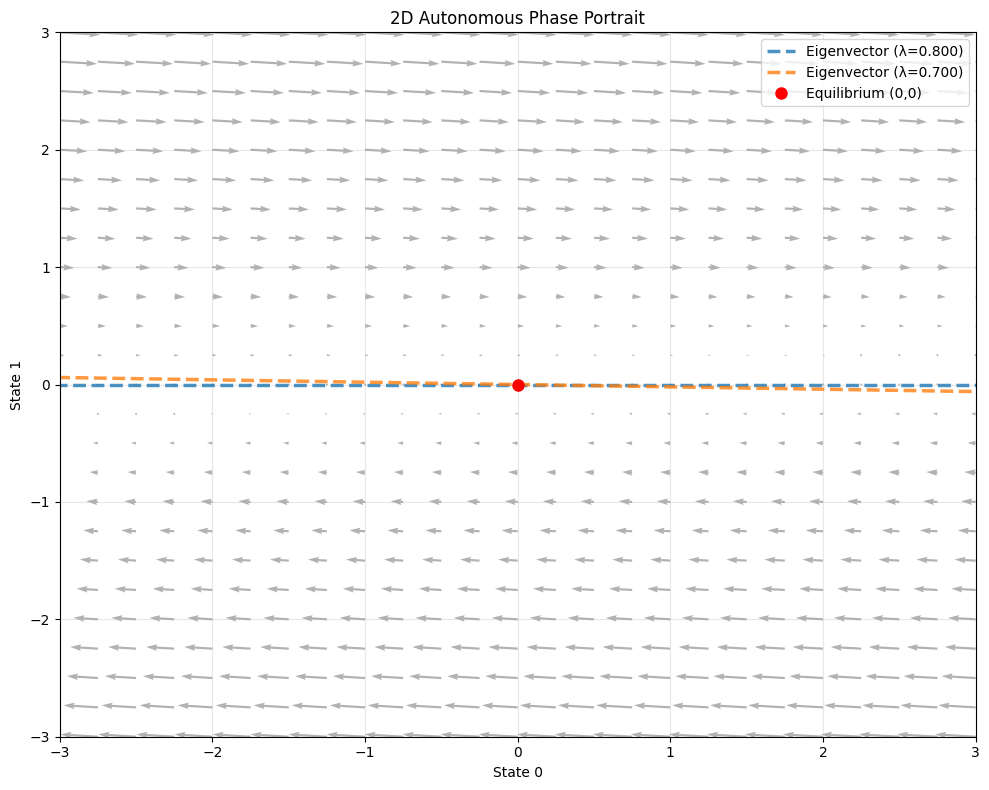

2. ESTIMATED Physics: The estimator was fooled by the transient surge.
It likely hallucinated eigenvalues > 1 (Unstable) to explain the temporary explosion.


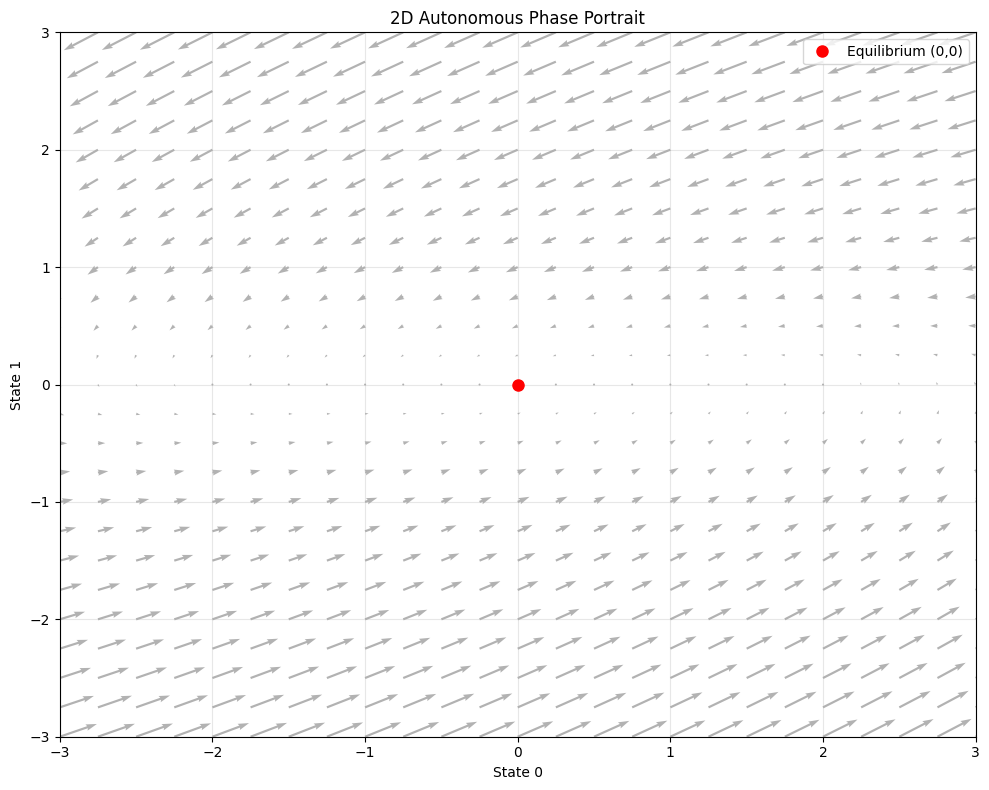


--- Running Case 2: Null-Space Injection ---
Hankel EM reached max iterations (100).


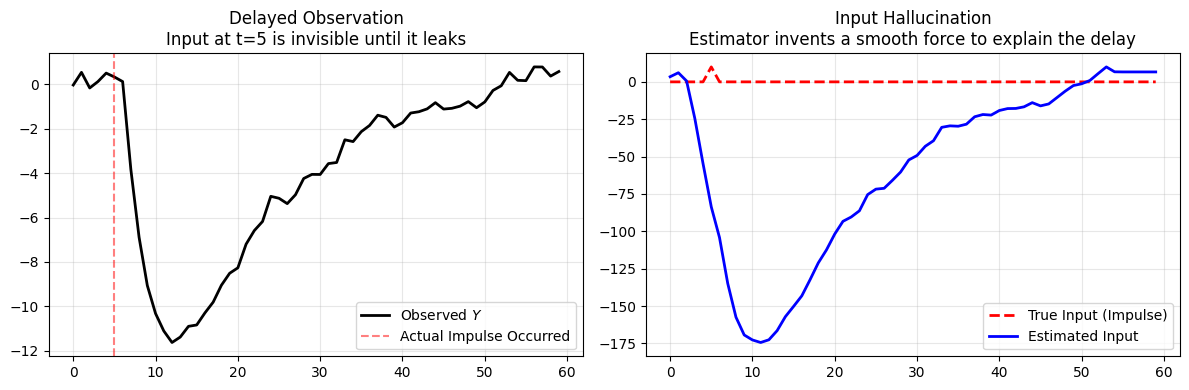


--- Running Case 4: The Hidden Oscillator (3D) ---
Hankel EM converged at iteration 12

[Visualizing Case 4 Phase Portraits]
1. TRUE Physics (3D): Notice the spiral dynamics dominating the vector field.


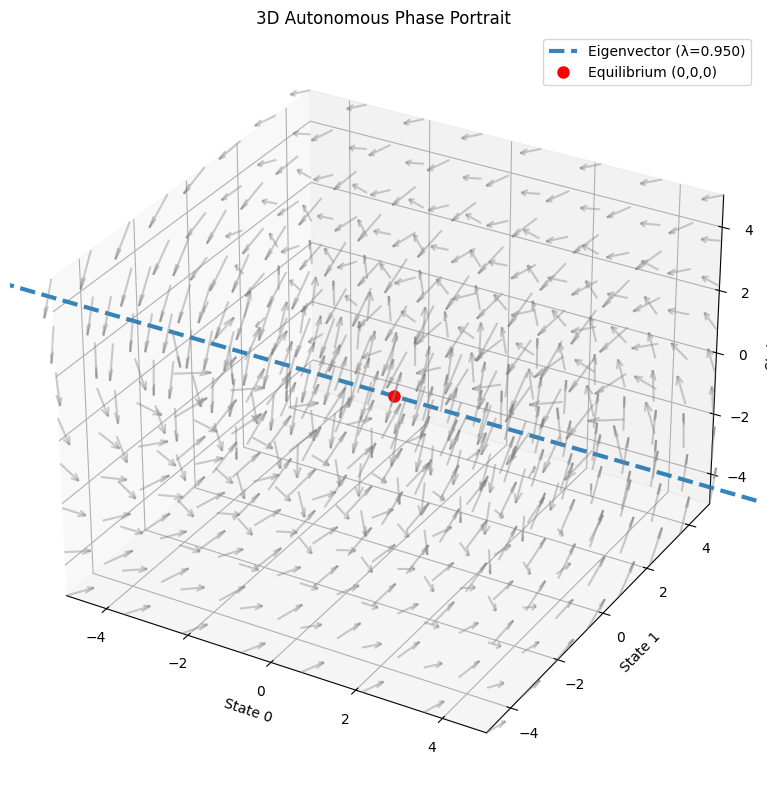

2. ESTIMATED Physics (3D): Did the Hankel matrix catch the spiral through the tiny C mapping?
If it failed, this 3D wireframe will look like a flattened, crushed saddle point.


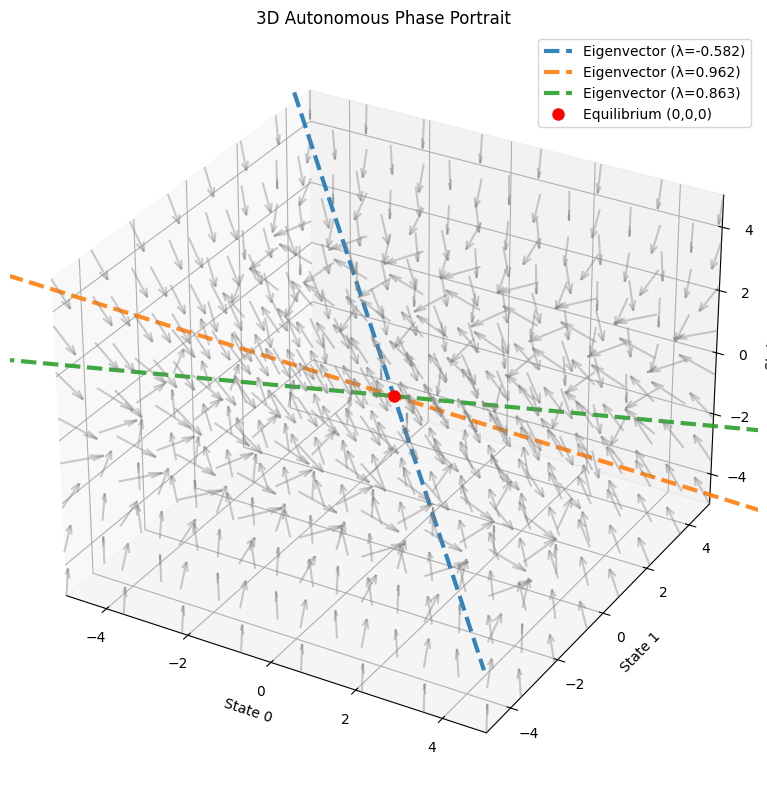

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la
'''1.Transient amplification caused by non-normal dynamics
    A transition matrix can be stable in terms of its eigenvalues, while still producing a large temporary increase in activity, mimicing the result of an input. This happens when the matrix is non-normal, meaning its eigenvectors are not orthogonal. In this case, different modes are not geometrically independent. Even if each eigenmode eventually decays, their directions can interfere constructively for a short time, producing a transient peak before the trajectory decays.

2.Input injection into the observation null-space
    An input may strongly affect the latent state but remain weakly visible in the observations, on the moment that it's applied. This happens when the input drives the system in directions that lie close to the null-space of the observation matrix. The effects could still be visible in an observable system, but with a delay. 

3.Ill-conditioned eigenbasis of the transition matrix
    Even if noise and inputs are balanced when injected into the latent space, the transition dynamics may transform them unevenly. If the transition matrix has highly unequal stretching directions, or if its eigenvectors are nearly linearly dependent, then some latent directions can accumulate much larger variance while others remain weak, short-lived, or difficult to identify. This can create apparent differences in variance and dominant temporal structure across latent dimensions. The conditioning does not create new true eigenfrequencies, but it can make different latent coordinates appear to contain different frequencies because the underlying modes are unevenly mixed.
'''
print("==================================================")
print(" SYSTEM ID PATHOLOGY TESTBENCH ")
print("==================================================")

# ==================================================
# EDGE CASE 1: Transient Amplification (Non-Normal)
# ==================================================
print("\n--- Running Case 1: Transient Amplification ---")
A_1 = np.array([[0.8, 5.0], [0.0, 0.7]]) # Highly non-normal
B_1 = np.zeros((2, 1))
C_1 = np.eye(2)
Q_1 = np.eye(2) * 0.01
R_1 = np.eye(2) * 0.05

def zero_control(time, data): return [0.0]

sim_case1_true = Simulator([A_1, B_1, C_1, Q_1, R_1])
# Start with purely state 2 excited to trigger the massive transient surge in state 1
data_1 = sim_case1_true.generate_data(trials=1, lengths=50, seed=[0.0, 1.0], control_function=zero_control)
Y_1 = data_1[0]

# Estimate
X_est_1, U_est_1, lds_est_1 = _estimate_hankel_markovian_em(Y_1, LatentDim=2, InputDim=1, num_delays=4, prior_lambda=0.0)

# Create a Simulator from the ESTIMATED matrices to plot its phase portrait
# (We pass the true Q and R just to satisfy the __init__ signature)
sim_case1_est = Simulator([lds_est_1.A, lds_est_1.B, lds_est_1.C, Q_1, R_1])

print("\n[Visualizing Case 1 Phase Portraits]")
print("1. TRUE Physics: Notice the eigenvalues are strictly < 1 (Stable).")
sim_case1_true.plot_phase_portrait(scale=3.0)

print("2. ESTIMATED Physics: The estimator was fooled by the transient surge.")
print("It likely hallucinated eigenvalues > 1 (Unstable) to explain the temporary explosion.")
sim_case1_est.plot_phase_portrait(scale=3.0)


# ==================================================
# EDGE CASE 2: Null-Space Injection
# ==================================================
print("\n--- Running Case 2: Null-Space Injection ---")
A_2 = np.array([[0.9, 0.5], [0.0, 0.8]])
B_2 = np.array([[1.0], [-1.0]])
C_2 = np.array([[1.0, 1.0]]) # Only observes the sum of states
Q_2 = np.eye(2) * 0.01
R_2 = np.array([[0.05]])

def impulse_control(time, data): 
    return [10.0] if time == 5 else [0.0] # Massive kick at t=5

sim_case2 = Simulator([A_2, B_2, C_2, Q_2, R_2])
data_2 = sim_case2.generate_data(trials=1, lengths=60, seed=[0.0, 0.0], control_function=impulse_control)
Y_2 = data_2[0]

# Estimate
X_est_2, U_est_2, lds_est_2 = _estimate_hankel_markovian_em(Y_2, LatentDim=2, InputDim=1, num_delays=4, prior_lambda=10.0)

# We will plot the True Input vs Estimated Input manually since phase space doesn't capture U
U_true_2 = np.array([impulse_control(t, [])[0] for t in range(60)])
U_est_scaled = U_est_2 * (np.max(U_true_2) / (np.max(U_est_2) + 1e-6))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(Y_2[:, 0], 'k-', lw=2, label="Observed $Y$")
ax[0].axvline(5, color='r', linestyle='--', alpha=0.5, label="Actual Impulse Occurred")
ax[0].set_title("Delayed Observation\nInput at t=5 is invisible until it leaks")
ax[0].legend(); ax[0].grid(True, alpha=0.3)

ax[1].plot(U_true_2[:len(U_est_scaled)], 'r--', lw=2, label="True Input (Impulse)")
ax[1].plot(U_est_scaled, 'b-', lw=2, label="Estimated Input")
ax[1].set_title("Input Hallucination\nEstimator invents a smooth force to explain the delay")
ax[1].legend(); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


# ==================================================
# EDGE CASE 4: The Hidden Oscillator (3D)
# ==================================================
print("\n--- Running Case 4: The Hidden Oscillator (3D) ---")
A_4 = np.array([
    [0.95, 0.0,  0.0],
    [0.0,  0.8, -0.5],
    [0.0,  0.5,  0.8]
]) # Slow decay + Fast Oscillator
B_4 = np.zeros((3, 1))
C_4 = np.array([[1.0, 0.05, 0.05]]) # Lens almost completely ignores the oscillator
Q_4 = np.eye(3) * 0.005
R_4 = np.array([[0.05]])

sim_case4_true = Simulator([A_4, B_4, C_4, Q_4, R_4])
data_4 = sim_case4_true.generate_data(trials=1, lengths=100, seed=[2.0, 5.0, 0.0], control_function=zero_control)
Y_4 = data_4[0]

# Estimate (We tell the estimator to look for 3 dimensions, and give it a wide delay window to catch the rotation)
X_est_4, U_est_4, lds_est_4 = _estimate_hankel_markovian_em(Y_4, LatentDim=3, InputDim=1, num_delays=10, prior_lambda=0.0)

sim_case4_est = Simulator([lds_est_4.A, lds_est_4.B, lds_est_4.C, Q_4, R_4])

print("\n[Visualizing Case 4 Phase Portraits]")
print("1. TRUE Physics (3D): Notice the spiral dynamics dominating the vector field.")
sim_case4_true.plot_phase_portrait(scale=5.0)

print("2. ESTIMATED Physics (3D): Did the Hankel matrix catch the spiral through the tiny C mapping?")
print("If it failed, this 3D wireframe will look like a flattened, crushed saddle point.")
sim_case4_est.plot_phase_portrait(scale=5.0)

 SYSTEM ID PATHOLOGY TESTBENCH 

--- Running Case 1: Transient Amplification ---
Hankel EM converged at iteration 6


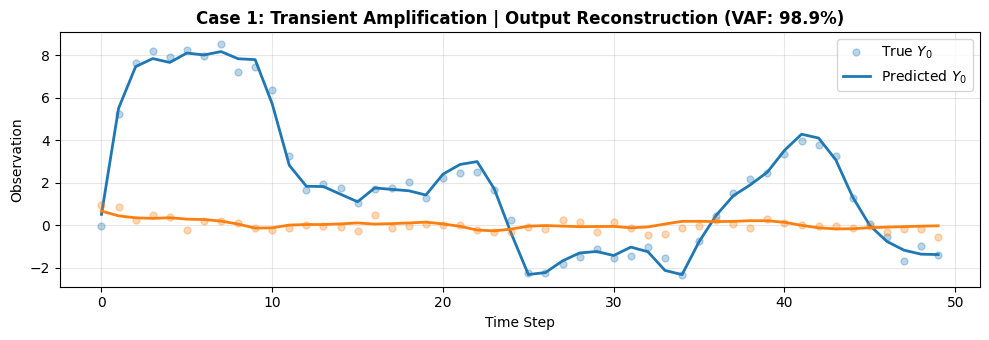

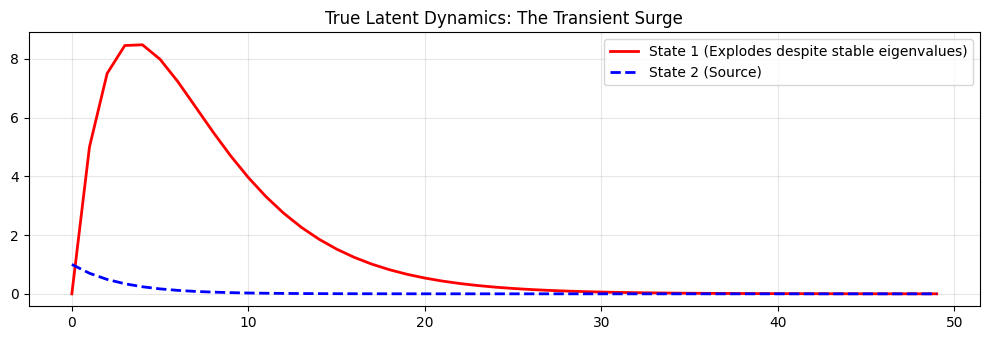

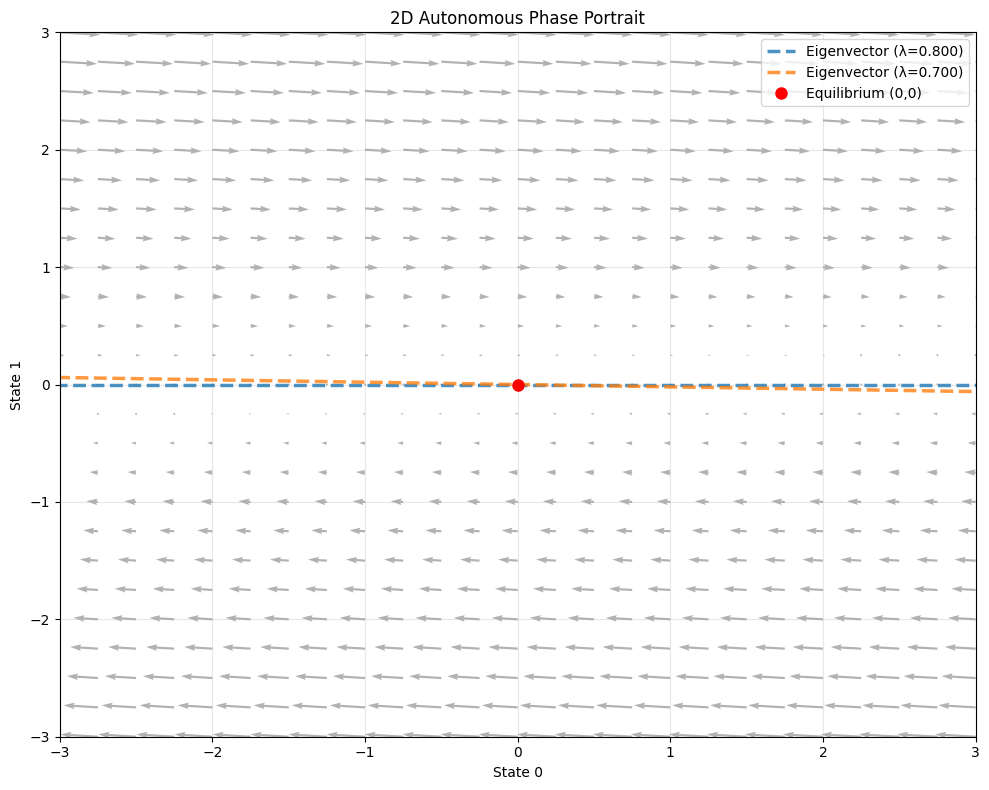

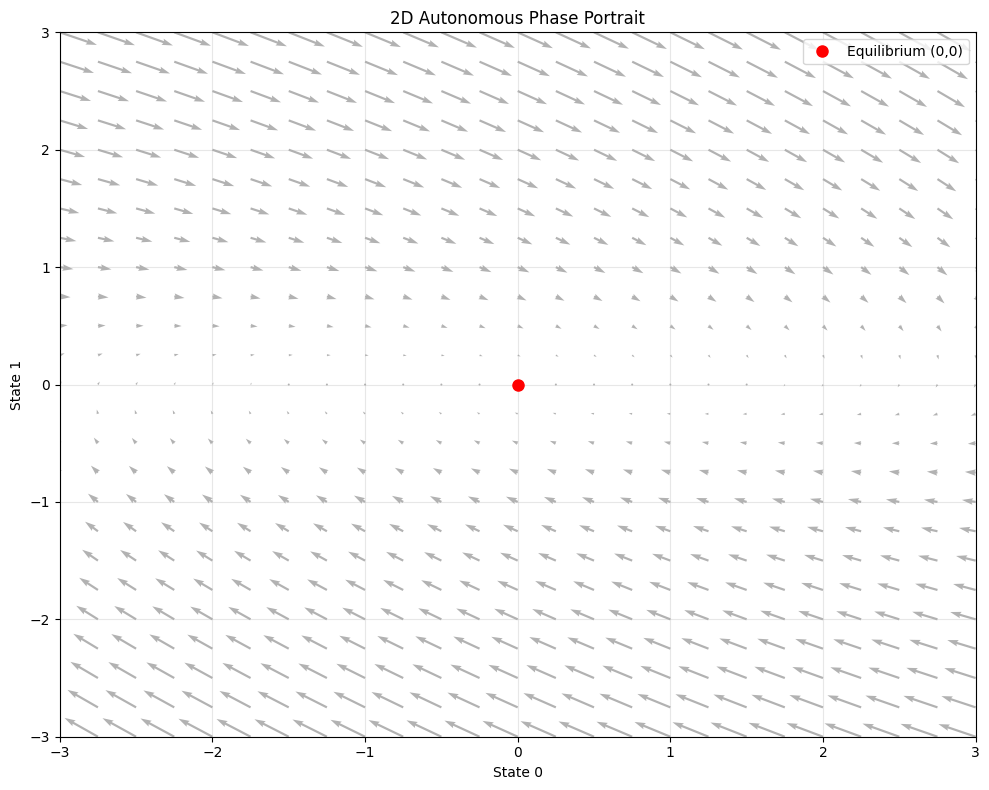


--- Running Case 2: Null-Space Injection ---
Hankel EM reached max iterations (100).


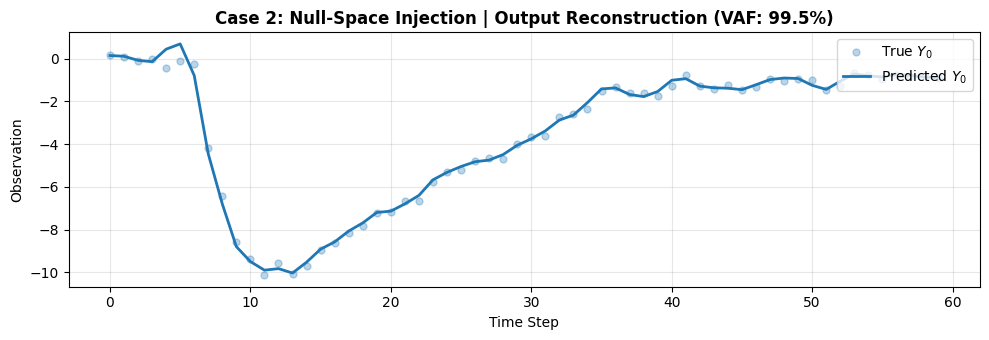

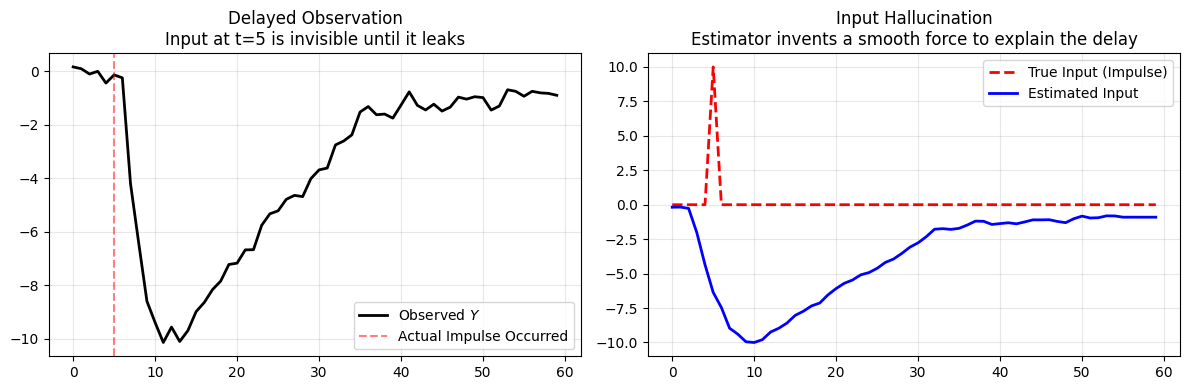


--- Running Case 3: Ill-Conditioned Eigenbasis ---
Hankel EM converged at iteration 7


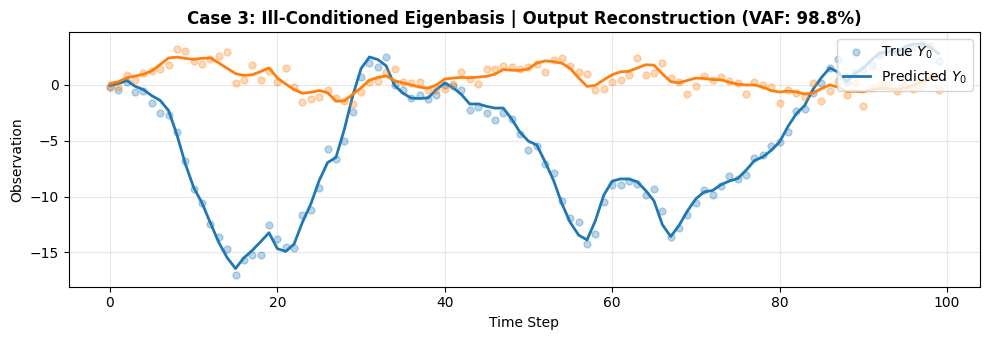

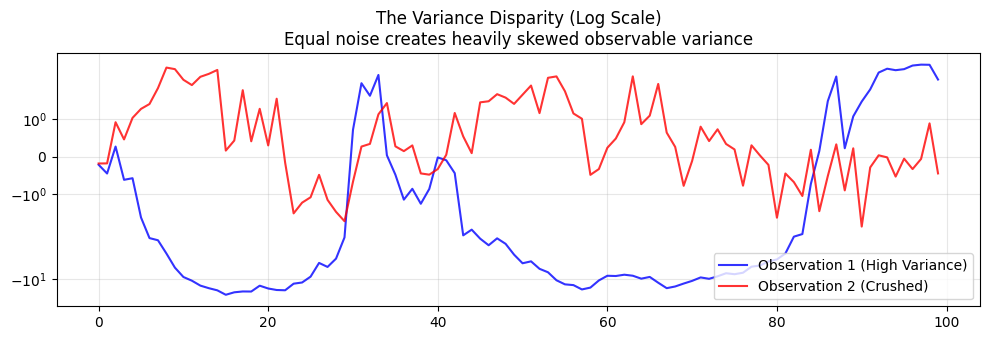


--- Running Case 4: The Hidden Oscillator (3D) ---
Hankel EM converged at iteration 18


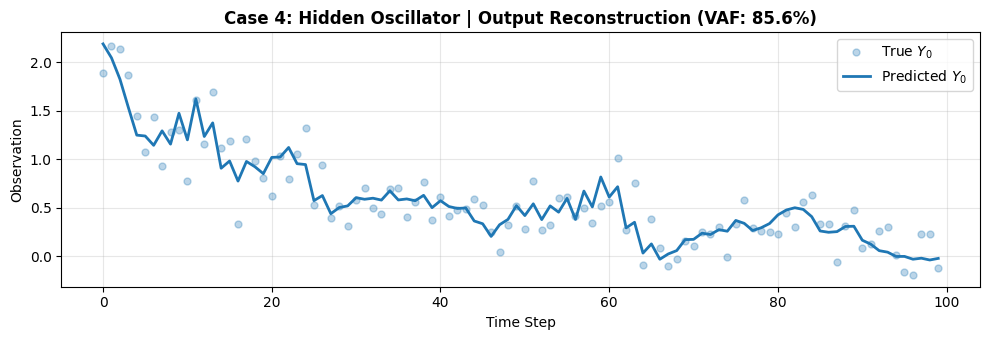

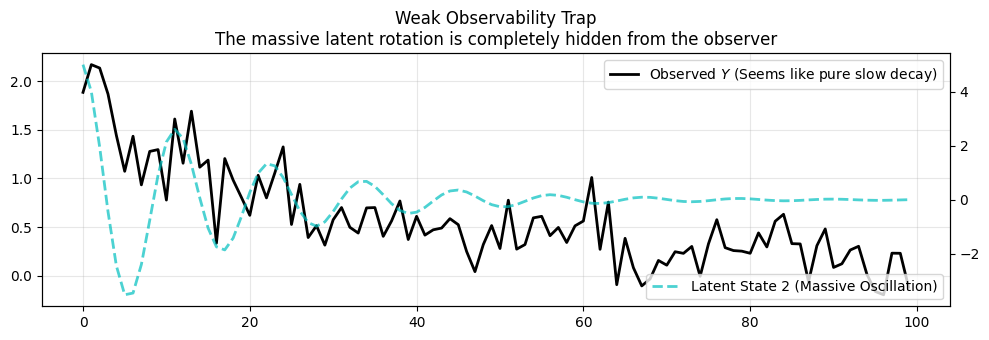

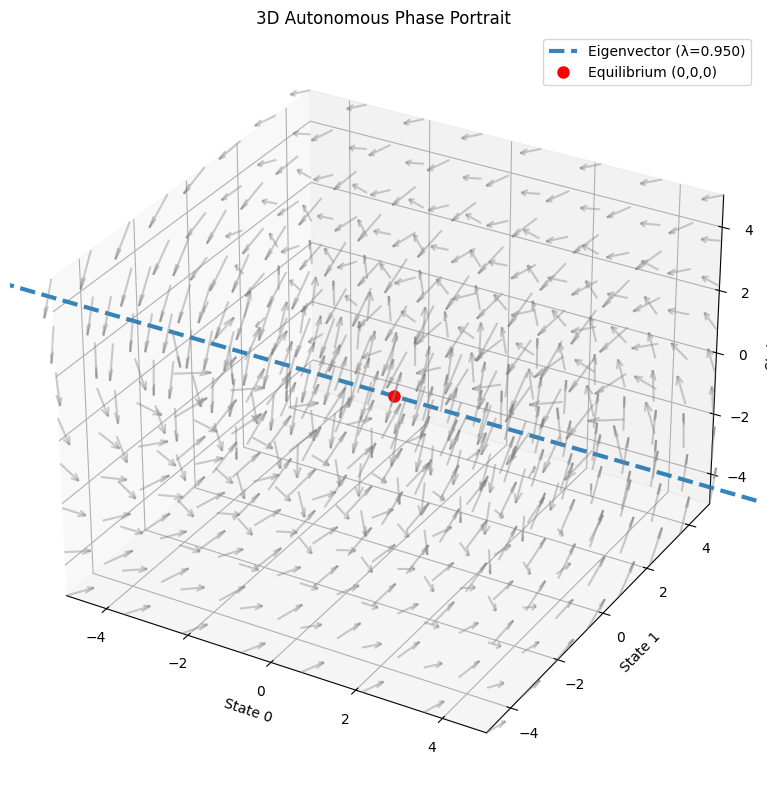

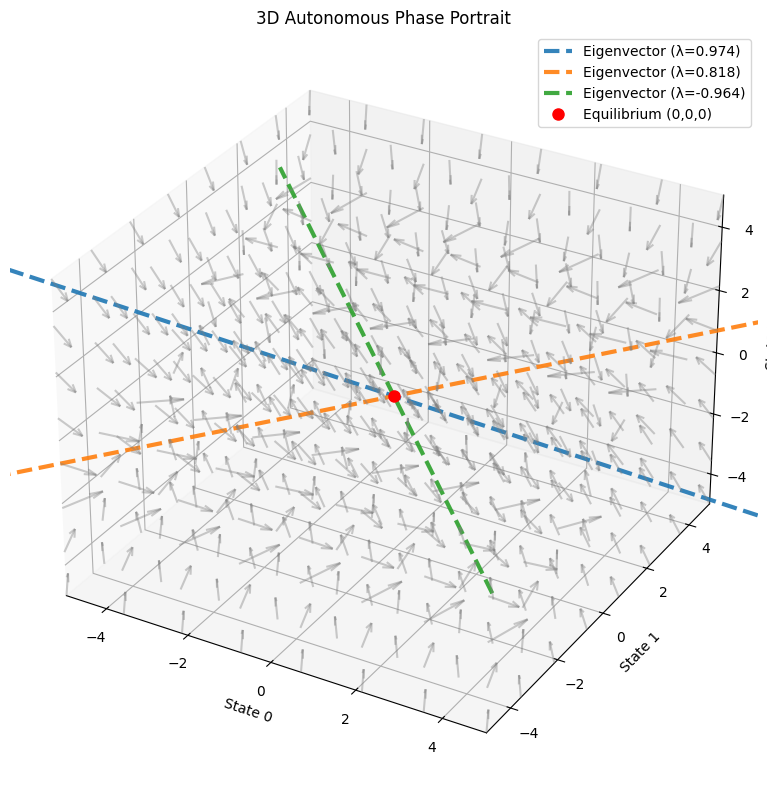

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

# Helper function to plot predicted vs true outputs cleanly
def plot_output_reconstruction(Y_true, Y_pred, title_prefix):
    # Truncate Y_true to match Y_pred length (due to Hankel delays)
    Y_t = Y_true[:len(Y_pred)]
    vaf = 100 * (1 - np.var(Y_t - Y_pred) / np.var(Y_t))
    
    fig, ax = plt.subplots(figsize=(10, 3.5))
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    for i in range(Y_t.shape[1]):
        c = colors[i % len(colors)]
        ax.plot(Y_t[:, i], '.', color=c, alpha=0.3, markersize=10, label=f"True $Y_{i}$" if i==0 else "")
        ax.plot(Y_pred[:, i], '-', color=c, lw=2, label=f"Predicted $Y_{i}$" if i==0 else "")
        
    ax.set_title(f"{title_prefix} | Output Reconstruction (VAF: {vaf:.1f}%)", fontweight='bold')
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Observation")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("==================================================")
print(" SYSTEM ID PATHOLOGY TESTBENCH ")
print("==================================================")

# ==================================================
# EDGE CASE 1: Transient Amplification (Non-Normal)
# ==================================================
print("\n--- Running Case 1: Transient Amplification ---")
A_1 = np.array([[0.8, 5.0], [0.0, 0.7]]) # Highly non-normal
B_1 = np.zeros((2, 1))
C_1 = np.eye(2)
Q_1 = np.eye(2) * 0.01
R_1 = np.eye(2) * 0.05

def zero_control(time, data): return [0.0]

sim_case1_true = Simulator([A_1, B_1, C_1, Q_1, R_1])
# Start with purely state 2 excited to trigger the massive transient surge in state 1
data_1 = sim_case1_true.generate_data(trials=1, lengths=50, seed=[0.0, 1.0], control_function=zero_control)
Y_1 = data_1[0]

# Estimate
X_est_1, U_est_1, lds_est_1 = _estimate_hankel_markovian_em(Y_1, LatentDim=2, InputDim=1, num_delays=4, prior_lambda=0.0)
Y_pred_1 = X_est_1 @ lds_est_1.C.T

# PLOT 1A: Output Reconstruction
plot_output_reconstruction(Y_1, Y_pred_1, "Case 1: Transient Amplification")

# PLOT 1B: True Latent State vs Phase Portraits
fig, ax = plt.subplots(figsize=(10, 3.5))
true_X_1 = np.zeros((50, 2))
true_X_1[0] = [0.0, 1.0]
for t in range(1, 50): true_X_1[t] = A_1 @ true_X_1[t-1]
ax.plot(true_X_1[:, 0], 'r-', lw=2, label="State 1 (Explodes despite stable eigenvalues)")
ax.plot(true_X_1[:, 1], 'b--', lw=2, label="State 2 (Source)")
ax.set_title("True Latent Dynamics: The Transient Surge")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

sim_case1_est = Simulator([lds_est_1.A, lds_est_1.B, lds_est_1.C, Q_1, R_1])
sim_case1_true.plot_phase_portrait(scale=3.0)
sim_case1_est.plot_phase_portrait(scale=3.0)


# ==================================================
# EDGE CASE 2: Null-Space Injection
# ==================================================
print("\n--- Running Case 2: Null-Space Injection ---")
A_2 = np.array([[0.9, 0.5], [0.0, 0.8]])
B_2 = np.array([[1.0], [-1.0]])
C_2 = np.array([[1.0, 1.0]]) # Only observes the sum of states
Q_2 = np.eye(2) * 0.01
R_2 = np.array([[0.05]])

def impulse_control(time, data): 
    return [10.0] if time == 5 else [0.0] # Massive kick at t=5

sim_case2 = Simulator([A_2, B_2, C_2, Q_2, R_2])
data_2 = sim_case2.generate_data(trials=1, lengths=60, seed=[0.0, 0.0], control_function=impulse_control)
Y_2 = data_2[0]

# Estimate
X_est_2, U_est_2, lds_est_2 = _estimate_hankel_markovian_em(Y_2, LatentDim=2, InputDim=1, num_delays=4, prior_lambda=10.0)
Y_pred_2 = X_est_2 @ lds_est_2.C.T

# PLOT 2A: Output Reconstruction
plot_output_reconstruction(Y_2, Y_pred_2, "Case 2: Null-Space Injection")

# PLOT 2B: Input Hallucination
U_true_2 = np.array([impulse_control(t, [])[0] for t in range(len(U_est_2))])
U_est_scaled = U_est_2 * (np.max(U_true_2) / (np.max(np.abs(U_est_2)) + 1e-6))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(Y_2[:, 0], 'k-', lw=2, label="Observed $Y$")
ax[0].axvline(5, color='r', linestyle='--', alpha=0.5, label="Actual Impulse Occurred")
ax[0].set_title("Delayed Observation\nInput at t=5 is invisible until it leaks")
ax[0].legend(); ax[0].grid(True, alpha=0.3)

ax[1].plot(U_true_2, 'r--', lw=2, label="True Input (Impulse)")
ax[1].plot(U_est_scaled, 'b-', lw=2, label="Estimated Input")
ax[1].set_title("Input Hallucination\nEstimator invents a smooth force to explain the delay")
ax[1].legend(); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


# ==================================================
# EDGE CASE 3: Ill-Conditioned Eigenbasis
# ==================================================
print("\n--- Running Case 3: Ill-Conditioned Eigenbasis ---")
V_ill = np.array([[1.0, 1.0], [0.0, 0.05]])
A_3 = V_ill @ np.diag([0.9, 0.85]) @ np.linalg.inv(V_ill)
B_3 = np.zeros((2, 1))
C_3 = np.eye(2)
Q_3 = np.eye(2) * 0.5 # High, equal process noise
R_3 = np.eye(2) * 0.1

sim_case3_true = Simulator([A_3, B_3, C_3, Q_3, R_3])
data_3 = sim_case3_true.generate_data(trials=1, lengths=100, seed=[0.0, 0.0], control_function=zero_control)
Y_3 = data_3[0]

# Estimate
X_est_3, U_est_3, lds_est_3 = _estimate_hankel_markovian_em(Y_3, LatentDim=2, InputDim=1, num_delays=4, prior_lambda=0.0)
Y_pred_3 = X_est_3 @ lds_est_3.C.T

# PLOT 3A: Output Reconstruction
plot_output_reconstruction(Y_3, Y_pred_3, "Case 3: Ill-Conditioned Eigenbasis")

# PLOT 3B: Variance disparity
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(Y_3[:, 0], 'b-', alpha=0.8, label="Observation 1 (High Variance)")
ax.plot(Y_3[:, 1], 'r-', alpha=0.8, label="Observation 2 (Crushed)")
ax.set_yscale('symlog')
ax.set_title("The Variance Disparity (Log Scale)\nEqual noise creates heavily skewed observable variance")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


# ==================================================
# EDGE CASE 4: The Hidden Oscillator (3D)
# ==================================================
print("\n--- Running Case 4: The Hidden Oscillator (3D) ---")
A_4 = np.array([
    [0.95, 0.0,  0.0],
    [0.0,  0.8, -0.5],
    [0.0,  0.5,  0.8]
]) # Slow decay + Fast Oscillator
B_4 = np.zeros((3, 1))
C_4 = np.array([[1.0, 0.05, 0.05]]) # Lens almost completely ignores the oscillator
Q_4 = np.eye(3) * 0.005
R_4 = np.array([[0.05]])

sim_case4_true = Simulator([A_4, B_4, C_4, Q_4, R_4])
data_4 = sim_case4_true.generate_data(trials=1, lengths=100, seed=[2.0, 5.0, 0.0], control_function=zero_control)
Y_4 = data_4[0]

# Estimate
X_est_4, U_est_4, lds_est_4 = _estimate_hankel_markovian_em(Y_4, LatentDim=3, InputDim=1, num_delays=10, prior_lambda=0.0)
Y_pred_4 = X_est_4 @ lds_est_4.C.T

# PLOT 4A: Output Reconstruction
plot_output_reconstruction(Y_4, Y_pred_4, "Case 4: Hidden Oscillator")

# PLOT 4B: Show the True Latent Oscillator vs What Y saw
fig, ax1 = plt.subplots(figsize=(10, 3.5))
ax2 = ax1.twinx()
true_X_4 = np.zeros((100, 3))
true_X_4[0] = [2.0, 5.0, 0.0]
for t in range(1, 100): true_X_4[t] = A_4 @ true_X_4[t-1]

ax1.plot(Y_4[:, 0], 'k-', lw=2, label="Observed $Y$ (Seems like pure slow decay)")
ax2.plot(true_X_4[:, 1], 'c--', lw=2, alpha=0.7, label="Latent State 2 (Massive Oscillation)")
ax1.set_title("Weak Observability Trap\nThe massive latent rotation is completely hidden from the observer")
ax1.legend(loc='upper right'); ax2.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

sim_case4_est = Simulator([lds_est_4.A, lds_est_4.B, lds_est_4.C, Q_4, R_4])
sim_case4_true.plot_phase_portrait(scale=5.0)
sim_case4_est.plot_phase_portrait(scale=5.0)

Exploiting Hankel with close oscillations

 THE ORTHOGONALITY EXPLOIT: NEARLY DEFECTIVE TRAP 
Running Hankel Estimator (Asking for LatentDim=2)...
Hankel EM converged at iteration 7


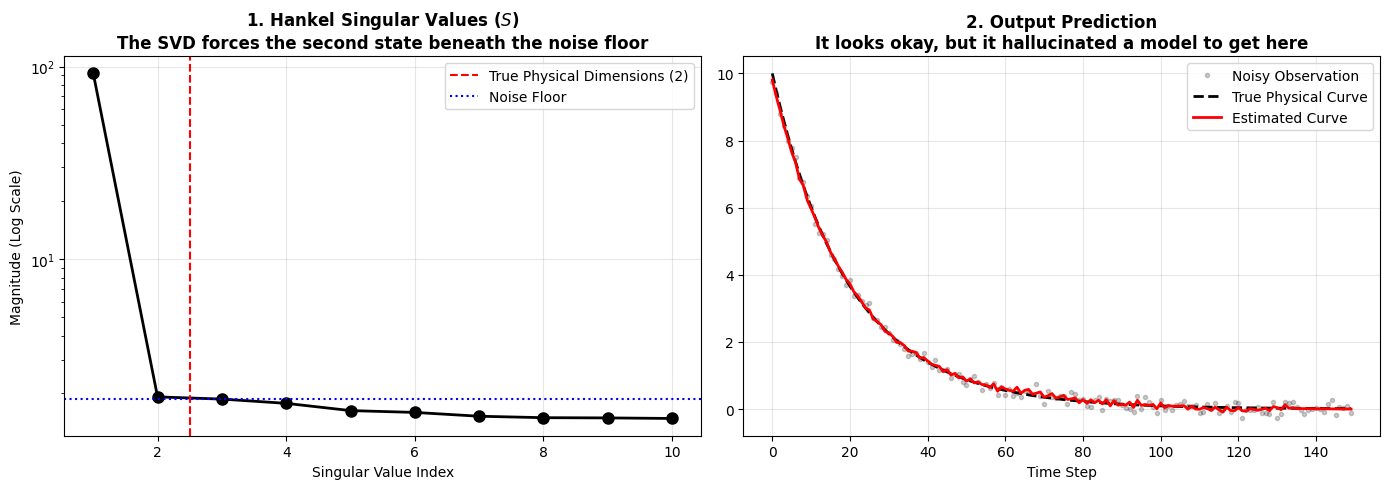


>>> Spawning TRUE Phase Portrait...
Notice the clean, independent axes. Both states just decay directly to zero.


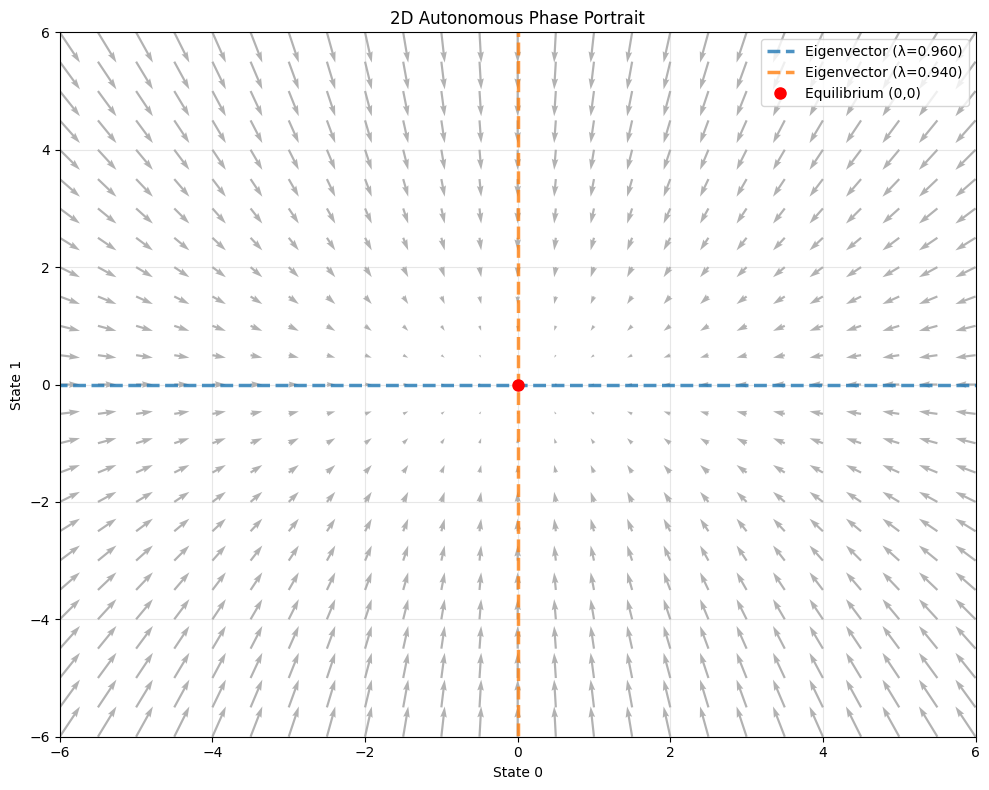


>>> Spawning ESTIMATED Phase Portrait...
Notice the complete destruction of the geometry. The estimator was forced to build an A matrix out of pure noise.


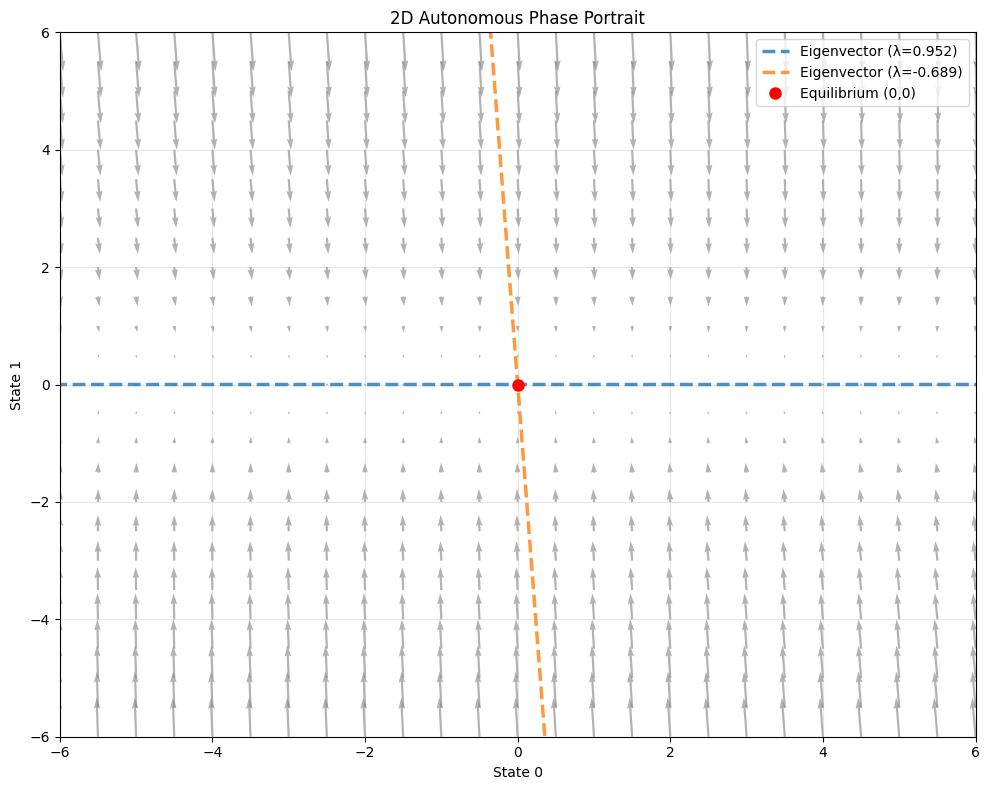

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la

# =====================================================================
# IMPORTS: Ensure your Simulator and _estimate_hankel_markovian_em are loaded
# =====================================================================

print("==================================================")
print(" THE ORTHOGONALITY EXPLOIT: NEARLY DEFECTIVE TRAP ")
print("==================================================")

# ==========================================
# 1. SETUP THE EXPLOIT (The True Physics)
# ==========================================
# Two nearly identical independent decays
A_true = np.array([[0.96, 0.0], 
                   [0.0,  0.94]]) 
B_true = np.zeros((2, 1))
C_true = np.array([[1.0, 1.0]]) # Observer sees the sum
Q_true = np.zeros((2, 2))       # No process noise, pure decay
R_true = np.array([[0.02]])     # Standard sensor noise

def zero_control(time, data): 
    return [0.0]

# Generate the true reality
sim_true = Simulator([A_true, B_true, C_true, Q_true, R_true])
Y_obs = sim_true.generate_data(trials=1, lengths=150, seed=[5.0, 5.0], control_function=zero_control)[0]

# Generate a perfectly clean version just for plotting the true curve
sim_clean = Simulator([A_true, B_true, C_true, np.zeros((2,2)), np.zeros((1,1))])
Y_clean = sim_clean.generate_data(trials=1, lengths=150, seed=[5.0, 5.0], control_function=zero_control)[0]

# ==========================================
# 2. RUN THE ESTIMATOR 
# ==========================================
print("Running Hankel Estimator (Asking for LatentDim=2)...")
# We explicitly ask for 2 dimensions. If the algorithm is robust, it should find them.
X_est, U_est, lds_est = _estimate_hankel_markovian_em(
    Y_obs, LatentDim=2, InputDim=1, num_delays=15, prior_lambda=0.0, max_iter=30
)

Y_pred = X_est @ lds_est.C.T

# ==========================================
# 3. PROVE THE MATHEMATICAL FAILURE
# ==========================================
# Manually build the Hankel matrix just to plot the singular values
num_delays = 15
T_h = len(Y_obs) - num_delays + 1
H = np.zeros((T_h, num_delays))
for i in range(num_delays):
    H[:, i:i+1] = Y_obs[i:T_h+i, :]
_, S_h, _ = la.svd(H, full_matrices=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot A: The Orthogonality Crush ---
axes[0].plot(np.arange(1, 11), S_h[:10], 'ko-', lw=2, markersize=8)
axes[0].axvline(2.5, color='r', linestyle='--', label="True Physical Dimensions (2)")
axes[0].axhline(S_h[2], color='blue', linestyle=':', label="Noise Floor")
axes[0].set_yscale('log')
axes[0].set_title("1. Hankel Singular Values ($S$)\nThe SVD forces the second state beneath the noise floor", fontweight='bold')
axes[0].set_xlabel("Singular Value Index")
axes[0].set_ylabel("Magnitude (Log Scale)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot B: The Output Illusion ---
T_trunc = len(Y_pred)
axes[1].plot(Y_obs[:T_trunc, 0], 'k.', alpha=0.2, label="Noisy Observation")
axes[1].plot(Y_clean[:T_trunc, 0], 'k--', lw=2, label="True Physical Curve")
axes[1].plot(Y_pred[:, 0], 'r-', lw=2, label="Estimated Curve")
axes[1].set_title("2. Output Prediction\nIt looks okay, but it hallucinated a model to get here", fontweight='bold')
axes[1].set_xlabel("Time Step")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 4. EXPOSE THE HALLUCINATION USING YOUR CLASS
# ==========================================
print("\n>>> Spawning TRUE Phase Portrait...")
print("Notice the clean, independent axes. Both states just decay directly to zero.")
sim_true.plot_phase_portrait(scale=6.0)

print("\n>>> Spawning ESTIMATED Phase Portrait...")
print("Notice the complete destruction of the geometry. The estimator was forced to build an A matrix out of pure noise.")
sim_est = Simulator([lds_est.A, lds_est.B, lds_est.C, Q_true, R_true])
sim_est.plot_phase_portrait(scale=6.0)

script to make tables

In [33]:
import numpy as np
import scipy.linalg as la
# Ensure Simulator, LDSParams, and your 3 estimator functions are imported here

def calculate_vaf(y_true, y_pred):
    return 100 * (1 - np.var(y_true - y_pred) / np.var(y_true))

# ==========================================
# 1. INPUT REGIMES
# ==========================================
def pulse_input(time, data): return [10.0] if time == 10 else [0.0]
def step_input(time, data): return [5.0] if time >= 20 else [0.0]
def sinusoidal_input(time, data): return [np.sin(time / 5.0)]
def chirp_input(time, data): return [np.sin(0.015 * time**2)]
def white_noise_input(time, data): return [np.random.randn() * 2.0]
def mixed_input(time, data): return [np.sin(time / 5.0) + np.random.randn() * 0.5]

input_regimes = {
    "Pulse": pulse_input,
    "Step": step_input,
    "Sine": sinusoidal_input,
    "Chirp": chirp_input,
    "White Noise": white_noise_input,
    "Mixed": mixed_input
}

# ==========================================
# 2. DEFINE THE TEST SYSTEM (Expanded to 4 Sensors)
# ==========================================
A_sys = np.array([[0.95, -0.15], 
                  [0.15,  0.95]])
B_sys = np.array([[0.5], [0.1]])

# Expand C to 4 sensors so the Naive PCA has enough dimensions to split
C_sys = np.array([
    [1.0,  0.5], 
    [0.0,  1.0],
    [-0.5, 0.5],
    [0.5, -0.5]
])

Q_sys = np.eye(2) * 0.01
R_sys = np.eye(4) * 0.05 # R must match the 4 sensors

sim_noisy = Simulator([A_sys, B_sys, C_sys, Q_sys, R_sys])
sim_clean = Simulator([A_sys, B_sys, C_sys, np.zeros((2,2)), np.zeros((4,4))])

# ==========================================
# 3. ALGORITHM WRAPPERS
# ==========================================
def run_naive(Y):
    return _estimate_all_parameters(Y, LatentDim=2, InputDim=1)

def run_standard_em(Y):
    return _estimate_markovian_gaussian_em(Y, LatentDim=2, InputDim=1, prior_lambda=50.0, max_iter=30)

def run_hankel_em(Y):
    return _estimate_hankel_markovian_em(Y, LatentDim=2, InputDim=1, num_delays=15, prior_lambda=50.0, max_iter=30)

architectures = {
    "Naive PCA Split": run_naive,
    "Standard Markovian EM": run_standard_em,
    "Hankel Markovian EM": run_hankel_em
}

results_matrix = {arch: {} for arch in architectures}

print("Running Algorithm Progression Evaluation Suite...\n")

# ==========================================
# 4. EXECUTE TEST MATRIX
# ==========================================
np.random.seed(42) 
T_len = 200

for input_name, control_func in input_regimes.items():
    print(f"-> Testing Input Regime: {input_name}")
    
    Y_noisy = sim_noisy.generate_data(trials=1, lengths=T_len, seed=[0.0, 0.0], control_function=control_func)[0]
    Y_true = sim_clean.generate_data(trials=1, lengths=T_len, seed=[0.0, 0.0], control_function=control_func)[0]
    
    for arch_name, estimator_func in architectures.items():
        try:
            X_est, U_est, lds_est = estimator_func(Y_noisy)
            Y_pred = X_est @ lds_est.C.T
            vaf_score = calculate_vaf(Y_true, Y_pred)
            results_matrix[arch_name][input_name] = vaf_score
            
        except Exception as e:
            print(f"  [!] {arch_name} failed on {input_name}: {e}")
            results_matrix[arch_name][input_name] = -999.0

print("\nEvaluation Complete. Generating LaTeX...\n")

# ==========================================
# 5. GENERATE LATEX OUTPUT
# ==========================================
latex_out = []
latex_out.append("\\begin{table}[h!]")
latex_out.append("\\centering")
latex_out.append("\\resizebox{\\textwidth}{!}{%")
latex_out.append("\\begin{tabular}{@{}l" + "c" * len(input_regimes) + "@{}}")
latex_out.append("\\toprule")

# Header Row
headers = ["\\textbf{Implemented Estimator}"] + [f"\\textbf{{{name}}}" for name in input_regimes.keys()]
latex_out.append(" & ".join(headers) + " \\\\ \\midrule")

# Data Rows
for arch_name in architectures.keys():
    row_str = f"{arch_name} "
    for input_name in input_regimes.keys():
        score = results_matrix[arch_name][input_name]
        
        if score < -100:
            row_str += "& Fail "
        elif score > 97.0:
            row_str += f"& \\textbf{{{score:.1f}\\%}} "
        else:
            row_str += f"& {score:.1f}\\% "
            
    row_str += "\\\\"
    latex_out.append(row_str)

latex_out.append("\\bottomrule")
latex_out.append("\\end{tabular}%")
latex_out.append("}")
latex_out.append("\\vspace{0.5em}")
latex_out.append("\\caption{\\textbf{Algorithm Progression Analysis:} Evaluation of the three developed estimators against a single 2D damped rotational system under varying control regimes. The observation matrix ($C$) utilizes 4 sensors to ensure full rank initialization. VAF calculated against noiseless physical ground-truth.}")
latex_out.append("\\label{tab:algorithm_progression}")
latex_out.append("\\end{table}")

print("==================================================")
print(" COPY AND PASTE THIS DIRECTLY INTO YOUR REPORT: ")
print("==================================================")
print("\n".join(latex_out))

Running Algorithm Progression Evaluation Suite...

-> Testing Input Regime: Pulse
Gaussian Markovian EM reached max iterations (30).
Hankel EM reached max iterations (30).
-> Testing Input Regime: Step
Gaussian Markovian EM reached max iterations (30).
Hankel EM reached max iterations (30).
-> Testing Input Regime: Sine
Gaussian Markovian EM reached max iterations (30).
Hankel EM reached max iterations (30).
-> Testing Input Regime: Chirp
Gaussian Markovian EM reached max iterations (30).
Hankel EM reached max iterations (30).
-> Testing Input Regime: White Noise
Gaussian Markovian EM reached max iterations (30).
Hankel EM reached max iterations (30).
-> Testing Input Regime: Mixed
Gaussian Markovian EM reached max iterations (30).
Hankel EM reached max iterations (30).

Evaluation Complete. Generating LaTeX...

 COPY AND PASTE THIS DIRECTLY INTO YOUR REPORT: 
\begin{table}[h!]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{@{}lcccccc@{}}
\toprule
\textbf{Implemented Estimator}

vaf analysis

 MULTI-SYSTEM ROBUSTNESS TEST (MONTE CARLO DEGRADATION) 
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel EM reached max iterations (30).
Hankel 

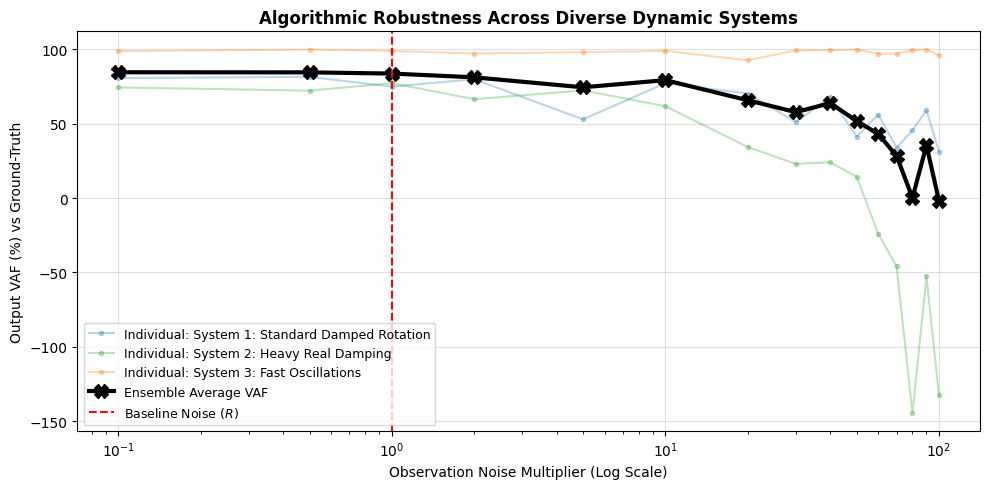

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_vaf(y_true, y_pred):
    return 100 * (1 - np.var(y_true - y_pred) / np.var(y_true))

def pulse_input(time, data):
    return [10.0] if time == 10 else [0.0]

print("==================================================")
print(" MULTI-SYSTEM ROBUSTNESS TEST (MONTE CARLO DEGRADATION) ")
print("==================================================")

# ==========================================
# 1. DEFINE A SUITE OF DIVERSE 2D SYSTEMS
# ==========================================
# Common matrices to isolate the test to internal dynamics (A)
B_base = np.array([[0.5], [0.1]])
C_base = np.array([[1.0, 0.5], [0.0, 1.0]])
Q_base = np.eye(2) * 0.01
R_base = np.eye(2) * 0.05

systems_suite = [
    {
        "name": "System 1: Standard Damped Rotation",
        "A": np.array([[0.95, -0.15], [0.15, 0.95]])
    },
    {
        "name": "System 2: Heavy Real Damping",
        "A": np.array([[0.90, 0.0], [0.0, 0.85]])
    },
    {
        "name": "System 3: Fast Oscillations",
        "A": np.array([[0.98, -0.30], [0.30, 0.98]])
    }
]

noise_multipliers = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0,20,30,40,50,60,70,80,90,100]
true_seed = [0.0, 0.0]
T_len = 150

# Dictionary to store the individual results for plotting
all_vaf_results = {sys["name"]: [] for sys in systems_suite}
average_vaf_scores = []

# ==========================================
# 2. RUN THE MULTI-SYSTEM DEGRADATION TEST
# ==========================================
for mult in noise_multipliers:
    current_noise_vafs = []
    
    for sys in systems_suite:
        # Scale the observation noise for this specific run
        R_test = R_base * mult
        
        # Initialize true and noisy simulators
        sim_clean = Simulator([sys["A"], B_base, C_base, np.zeros_like(Q_base), np.zeros_like(R_base)])
        sim_noisy = Simulator([sys["A"], B_base, C_base, Q_base, R_test])
        
        # Generate data
        Y_true = sim_clean.generate_data(trials=1, lengths=T_len, seed=true_seed, control_function=pulse_input)[0]
        Y_test = sim_noisy.generate_data(trials=1, lengths=T_len, seed=true_seed, control_function=pulse_input)[0]
        
        # Run Estimator
        X_est, U_est, lds = _estimate_hankel_markovian_em(
            Y_test, 
            LatentDim=2, 
            InputDim=1, 
            num_delays=10, 
            prior_lambda=50.0,
            max_iter=30
        )
        
        # Predict and Score
        Y_pred = X_est @ lds.C.T
        vaf = calculate_vaf(Y_true[:len(Y_pred)], Y_pred)
        
        all_vaf_results[sys["name"]].append(vaf)
        current_noise_vafs.append(vaf)
        
    # Calculate the mean VAF across all tested systems for this noise level
    average_vaf_scores.append(np.mean(current_noise_vafs))

# ==========================================
# 3. VISUALIZATION (Report Ready)
# ==========================================
plt.figure(figsize=(10, 5))

# Plot the individual systems as faint background lines
colors = ['tab:blue', 'tab:green', 'tab:orange']
for idx, (name, vafs) in enumerate(all_vaf_results.items()):
    plt.plot(noise_multipliers, vafs, color=colors[idx], marker='.', linestyle='-', 
             linewidth=1.5, alpha=0.3, label=f"Individual: {name}")

# Plot the bold average line over the top
plt.plot(noise_multipliers, average_vaf_scores, 'kX-', lw=3, markersize=10, 
         label="Ensemble Average VAF")

plt.xscale('log')
plt.title(r'Algorithmic Robustness Across Diverse Dynamic Systems', fontweight='bold')
plt.xlabel('Observation Noise Multiplier (Log Scale)')
plt.ylabel('Output VAF (%) vs Ground-Truth')
plt.grid(True, alpha=0.4)
plt.axvline(1.0, color='r', linestyle='--', label='Baseline Noise ($R$)')

# Position legend outside if it gets too crowded, or use best
plt.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()